# Medical QA RAG with Faithfulness Evaluation
### RAI-8001 Applied NLP for Assessment 2

This notebook implements a Retrieval-Augmented Generation pipeline for biomedical question answering using PubMedQA. The system compares sparse (BM25), dense (MedCPT), and hybrid retrieval strategies and it generates answers via LLM. It then evaluates both accuracy and faithfulness using a domain-specific biomedical NLI model.

In [ ]:
!pip install -q rank_bm25 faiss-cpu anthropic datasets sentence-transformers wordcloud nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.8/478.8 kB 44.5 MB/s eta 0:00:00


In [ ]:
# Mount Google Drive & Set Up Project Paths
# Persist data and intermediate results to Drive so that expensive operations survive Colab session timeouts

from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/pubmedqa-rag'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RAW_DIR = os.path.join(DATA_DIR, 'raw')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'outputs')

for d in [RAW_DIR, PROCESSED_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print("Directory structure created.")

Mounted at /content/drive
Project directory: /content/drive/MyDrive/pubmedqa-rag
Directory structure created.


## Session Recovery

If the session disconnects, this cell reloads previously saved intermediate results from Google Drive, skipping expensive recomputation

In [ ]:
# Imports and Configuration

# Data handling
import json
import numpy as np
import pandas as pd
import pickle
import os
import time
from typing import List, Dict, Tuple
from collections import Counter

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from rank_bm25 import BM25Okapi
import faiss
from transformers import (AutoTokenizer, AutoModel, AutoModelForSequenceClassification)
from sentence_transformers import SentenceTransformer
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report)
import torch
from tqdm.auto import tqdm

# LLM API
from anthropic import Anthropic
from google.colab import userdata

# NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# API client
ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
client = Anthropic(api_key=ANTHROPIC_API_KEY)
print("Anthropic client initialised.")

Using device: cuda
GPU: Tesla T4
Anthropic client initialised.


In [ ]:
recovery_status = {}

# Check for parsed DataFrames
if os.path.exists(os.path.join(PROCESSED_DIR, 'df_l.pkl')):
    df_l = pd.read_pickle(os.path.join(PROCESSED_DIR, 'df_l.pkl'))
    df_u = pd.read_pickle(os.path.join(PROCESSED_DIR, 'df_u.pkl'))
    recovery_status['dataframes'] = True
    print(f"✓ DataFrames loaded — PQA-L: {len(df_l)}, PQA-U: {len(df_u)}")
else:
    recovery_status['dataframes'] = False
    print("✗ DataFrames not found — will parse from scratch")

# Check for BM25 index
if os.path.exists(os.path.join(PROCESSED_DIR, 'bm25_index.pkl')):
    with open(os.path.join(PROCESSED_DIR, 'bm25_index.pkl'), 'rb') as f:
        bm25_index = pickle.load(f)
    recovery_status['bm25'] = True
    print("✓ BM25 index loaded")
else:
    recovery_status['bm25'] = False
    print("✗ BM25 index not found — will build when needed")

# Check for MedCPT FAISS index and embeddings
if os.path.exists(os.path.join(PROCESSED_DIR, 'medcpt_index.faiss')):
    faiss_index = faiss.read_index(os.path.join(PROCESSED_DIR, 'medcpt_index.faiss'))
    recovery_status['faiss'] = True
    print("✓ FAISS index loaded")
else:
    recovery_status['faiss'] = False
    print("✗ FAISS index not found — will build when needed")

# Check for generation results
for retriever in ['bm25', 'dense', 'hybrid']:
    path = os.path.join(PROCESSED_DIR, f'results_{retriever}.pkl')
    if os.path.exists(path):
        recovery_status[f'results_{retriever}'] = True
        print(f"✓ Generation results ({retriever}) loaded")
    else:
        recovery_status[f'results_{retriever}'] = False
        print(f"✗ Generation results ({retriever}) not found")

print(f"\nRecovery summary: {sum(recovery_status.values())}/{len(recovery_status)} stages available")

✓ DataFrames loaded — PQA-L: 1000, PQA-U: 61249
✓ BM25 index loaded
✓ FAISS index loaded
✓ Generation results (bm25) loaded
✓ Generation results (dense) loaded
✓ Generation results (hybrid) loaded

Recovery summary: 6/6 stages available


## 1. Data Loading: load PubMedQA Dataset

Two subsets of PubMedQA (Jin et al., 2019) are used:

- **PQA-L** (Labeled): 1,000 expert-annotated QA pairs - evaluation set
- **PQA-U** (Unlabeled): 61,200 QA pairs - retrieval corpus

Each instance contains a research question, structured abstract sections (context), the abstract's conclusion (long answer), and a yes/no/maybe label annotated by MD candidates for the PQA-L.

In [ ]:
from datasets import load_dataset



    # PQA-L: labeled subset - evaluation
pqa_l = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")

    # PQA-U: unlabeled subset - retrieval corpus
pqa_u = load_dataset("qiaojin/PubMedQA", "pqa_unlabeled", split="train")

print(f"PQA-L (labeled):   {len(pqa_l):,} instances")
print(f"PQA-U (unlabeled): {len(pqa_u):,} instances")
print(f"\nFeatures (PQA-L): {list(pqa_l.features.keys())}")
print(f"Features (PQA-U): {list(pqa_u.features.keys())}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

pqa_unlabeled/train-00000-of-00001.parqu(…):   0%|          | 0.00/66.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61249 [00:00<?, ? examples/s]

PQA-L (labeled):   1,000 instances
PQA-U (unlabeled): 61,249 instances

Features (PQA-L): ['pubid', 'question', 'context', 'long_answer', 'final_decision']
Features (PQA-U): ['pubid', 'question', 'context', 'long_answer']


In [ ]:
# Data structure check
sample = pqa_l[0]
for key, val in sample.items():
    if isinstance(val, str):
        print(f"{key} (str): {val[:150]}")
    elif isinstance(val, list):
        print(f"{key} (list, len={len(val)}): {val[0][:100] if val else 'empty'}")
    elif isinstance(val, dict):
        print(f"{key} (dict, keys={list(val.keys())})")
    else:
        print(f"{key} ({type(val).__name__}): {val}")

pubid (int): 21645374
question (str): Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
context (dict, keys=['contexts', 'labels', 'meshes', 'reasoning_required_pred', 'reasoning_free_pred'])
long_answer (str): Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other or
final_decision (str): yes


In [ ]:
# Inspect Context Structure

sample = pqa_l[0]
print(f"Section labels: {sample['context']['labels']}")
print(f"Number of sections: {len(sample['context']['contexts'])}")
print(f"MeSH terms: {sample['context']['meshes'][:5]}")
print()

for i, (label, text) in enumerate(zip(sample['context']['labels'],
                                       sample['context']['contexts'])):
    print(f"[{label}]: {text[:150]}")
    print()

print(f"{sample['long_answer'][:150]}")
print(sample['final_decision'])

# Analyse Context Structure Across PQA-L
# Check how section counts, and labels vary across the dataset to define the chunking strategy

# Section count distribution
section_counts = [len(entry['context']['contexts']) for entry in pqa_l]
print(f"Sections per abstract — min: {min(section_counts)}, "
      f"max: {max(section_counts)}, mean: {np.mean(section_counts):.1f}")

# Most common label combinations
all_labels = [tuple(entry['context']['labels']) for entry in pqa_l]
label_combos = Counter(all_labels)
print(f"\nUnique label combinations: {len(label_combos)}")
print("\nTop 10 most common:")
for combo, count in label_combos.most_common(10):
    print(f"  {combo}: {count}")

# Individual label frequency
flat_labels = [l for entry in pqa_l for l in entry['context']['labels']]
print(f"\nIndividual label frequencies:")
for label, count in Counter(flat_labels).most_common():
    print(f"  {label}: {count}")

Section labels: ['BACKGROUND', 'RESULTS']
Number of sections: 2
MeSH terms: ['Alismataceae', 'Apoptosis', 'Cell Differentiation', 'Mitochondria', 'Plant Leaves']

[BACKGROUND]: Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in 

[RESULTS]: The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole

Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other or
yes
Sections per abstract — min: 1, max: 9, mean: 3.4

Unique label combinations: 264

Top 10 most common:
  ('BACKGROUND', 'METHODS', 'RESULTS'): 242
  ('OBJECTIVE', 'METHODS', 'RESULTS'): 93
  ('PURPOSE', 'METHODS', 'RESULTS'): 58
  ('OBJECTIVES', 'METHODS', 'RESULTS'): 43
  ('METHODS', 'RESULTS'): 24
  ('INTRODUCTION', 'METHODS', 'RESULTS'): 19
  ('BAC

## 1.1 Data Parsing

Concatenate abstract sections into a single context string per instance and convert both subsets to DataFrames for easier manipulation. Section labels are preserved as metadata for analysis.

In [ ]:
# Parse Raw Data into DataFrames

if recovery_status.get('dataframes'):
    print("DataFrames already loaded from Drive — skipping parsing.")
    print(f"PQA-L shape: {df_l.shape}")
    print(f"PQA-U shape: {df_u.shape}")
else:
    def parse_pqa_entry(entry, has_label=True):
        """Parse a single PubMedQA entry into a flat dictionary"""
        sections = entry['context']['contexts']
        labels = entry['context']['labels']
        context_joined = " ".join(sections)

        parsed = {
            'pubid': entry['pubid'],
            'question': entry['question'],
            'context': context_joined,
            'long_answer': entry['long_answer'],
            'num_sections': len(sections),
            'section_labels': labels,
            'meshes': entry['context']['meshes'],
        }

        if has_label:
            parsed['label'] = entry['final_decision']

        return parsed

    df_l = pd.DataFrame([parse_pqa_entry(e, has_label=True) for e in pqa_l])
    df_u = pd.DataFrame([parse_pqa_entry(e, has_label=False) for e in pqa_u])

    # Save to Drive
    df_l.to_pickle(os.path.join(PROCESSED_DIR, 'df_l.pkl'))
    df_u.to_pickle(os.path.join(PROCESSED_DIR, 'df_u.pkl'))

    print(f"PQA-L shape: {df_l.shape}")
    print(f"PQA-U shape: {df_u.shape}")
    print("DataFrames saved to Drive.")

print(f"\nPQA-L columns: {list(df_l.columns)}")
df_l.head(2)

DataFrames already loaded from Drive — skipping parsing.
PQA-L shape: (1000, 11)
PQA-U shape: (61249, 10)

PQA-L columns: ['pubid', 'question', 'context', 'long_answer', 'num_sections', 'section_labels', 'meshes', 'label', 'question_len', 'context_len', 'long_answer_len']


,pubid,question,context,long_answer,num_sections,section_labels,meshes,label,question_len,context_len,long_answer_len
0,21645374,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,Results depicted mitochondrial dynamics in viv...,2,"[BACKGROUND, RESULTS]","[Alismataceae, Apoptosis, Cell Differentiation...",yes,14,251,97
1,16418930,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,"Using the charts described, there was only a s...",3,"[BACKGROUND, PATIENTS AND METHODS, RESULTS]","[Adolescent, Adult, Aged, Aged, 80 and over, A...",no,10,245,38


## 1.2 Data Quality Check

Before EDA, we verify data integrity: missing values, duplicates, empty fields, and overlap between the labelled and unlabeled subsets

In [ ]:
# Data quality check
print("Missing Values (PQA-L / PQA-U)")
print(f"PQA-L: {df_l.isnull().sum().sum()} total missing values")
print(f"PQA-U: {df_u.isnull().sum().sum()} total missing values")

print(f"\nDuplicates")
print(f"PQA-L duplicate PubIDs: {df_l['pubid'].duplicated().sum()}")
print(f"PQA-U duplicate PubIDs: {df_u['pubid'].duplicated().sum()}")

print(f"\nEmpty Contexts")
print(f"PQA-L: {(df_l['context'].str.strip() == '').sum()}")
print(f"PQA-U: {(df_u['context'].str.strip() == '').sum()}")

print(f"\nPubID Overlap (PQA-L vs PQA-U)")
overlap = set(df_l['pubid']).intersection(set(df_u['pubid']))
print(f"Shared PubIDs: {len(overlap)}")

Missing Values (PQA-L / PQA-U)
PQA-L: 0 total missing values
PQA-U: 0 total missing values

Duplicates
PQA-L duplicate PubIDs: 0
PQA-U duplicate PubIDs: 0

Empty Contexts
PQA-L: 0
PQA-U: 0

PubID Overlap (PQA-L vs PQA-U)
Shared PubIDs: 0


## 2. Exploratory Data Analysis

The next steo is the exploration of both PQA-L (evaluation set) and PQA-U (retrieval corpus) to understand label distributions, text characteristics, vocabulary patterns, and data quality before building the pipeline

### 2.1 Label Distribution

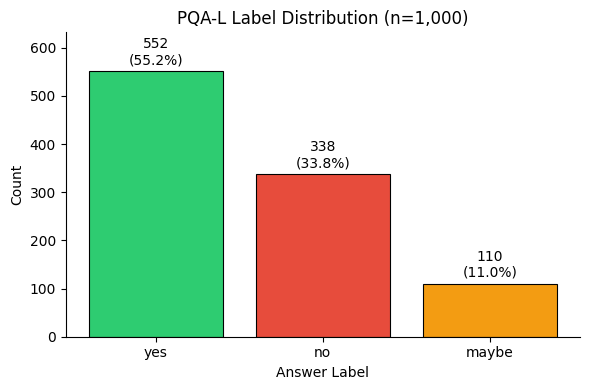

Majority class: 'yes' (55.2%)
Minority class: 'maybe' (11.0%)
Imbalance ratio (majority/minority): 5.02


In [ ]:
# Label Distribution (PQA-L)
label_counts = df_l['label'].value_counts()
label_pcts = df_l['label'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(label_counts.index, label_counts.values, color=colors,
              edgecolor='black', linewidth=0.8)

for bar, count, pct in zip(bars, label_counts.values, label_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Answer Label')
ax.set_ylabel('Count')
ax.set_title('PQA-L Label Distribution (n=1,000)')
ax.set_ylim(0, max(label_counts.values) + 80)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'label_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
print(f"Majority class: '{label_counts.index[0]}' ({label_pcts.iloc[0]:.1f}%)")
print(f"Minority class: '{label_counts.index[-1]}' ({label_pcts.iloc[-1]:.1f}%)")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

**Observations:** The dataset exhibits a notable class imbalance: "yes" answers dominate at 55.2%, while "maybe" accounts for only 11.0% (imbalance ratio 5.02:1). This has two implications: (1) a majority-class baseline achieves 55.2% accuracy, so the models must exceed this to have value; (2) accuracy cannot be used alone and **macro F1** will be the primary evaluation metric to weight all classes equally.

### 2.2 Text Length Distributions

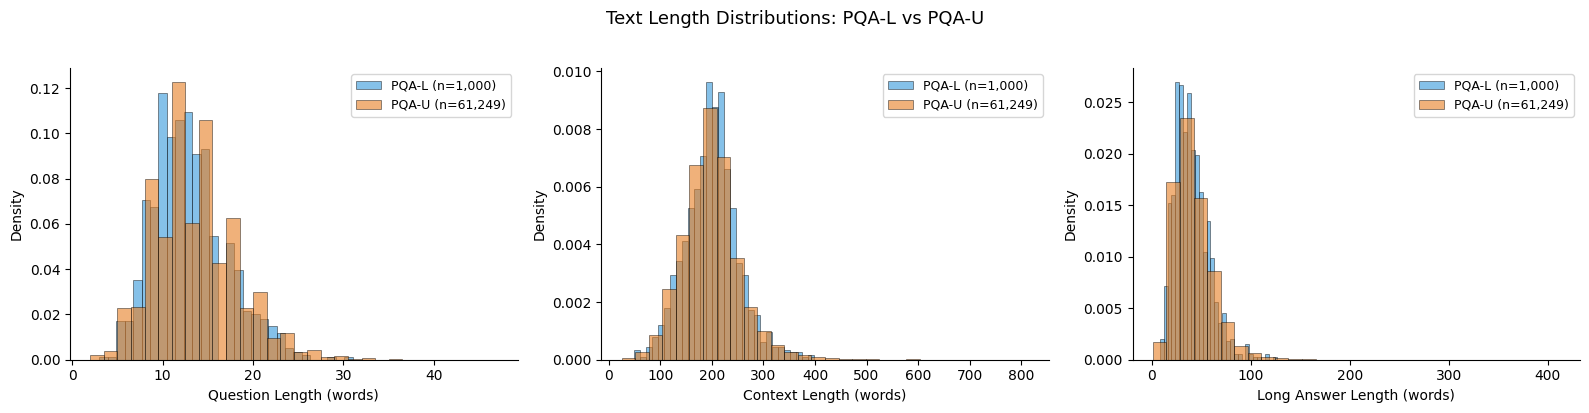

PQA-L Summary Statistics (words)
       question_len  context_len  long_answer_len
count        1000.0       1000.0           1000.0
mean           12.9        200.2             39.7
std             4.1         51.8             17.2
min             3.0         49.0              8.0
25%            10.0        166.8             27.0
50%            13.0        200.5             37.0
75%            15.0        228.0             49.0
max            31.0        398.0            126.0

PQA-U Summary Statistics (words)
       question_len  context_len  long_answer_len
count       61249.0      61249.0          61249.0
mean           13.3        198.7             42.0
std             4.6         56.7             19.8
min             2.0         25.0              1.0
25%            10.0        164.0             28.0
50%            13.0        197.0             39.0
75%            16.0        227.0             52.0
max            47.0        814.0            412.0


In [ ]:
# Text Length Distributions
# Compare question, context, and long answer lengths across PQA-L and PQA-U.
# Lengths measured in words

# Compute word counts
for df in [df_l, df_u]:
    df['question_len'] = df['question'].str.split().str.len()
    df['context_len'] = df['context'].str.split().str.len()
    df['long_answer_len'] = df['long_answer'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

fields = [
    ('question_len', 'Question Length (words)'),
    ('context_len', 'Context Length (words)'),
    ('long_answer_len', 'Long Answer Length (words)')
]

for ax, (col, title) in zip(axes, fields):
    ax.hist(df_l[col], bins=30, alpha=0.6, density=True,
            label=f'PQA-L (n={len(df_l):,})', color='#3498db',
            edgecolor='black', linewidth=0.5)
    ax.hist(df_u[col], bins=30, alpha=0.6, density=True,
            label=f'PQA-U (n={len(df_u):,})', color='#e67e22',
            edgecolor='black', linewidth=0.5)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Text Length Distributions: PQA-L vs PQA-U', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'text_length_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("PQA-L Summary Statistics (words)")
print(df_l[['question_len', 'context_len', 'long_answer_len']].describe().round(1))
print("\nPQA-U Summary Statistics (words)")
print(df_u[['question_len', 'context_len', 'long_answer_len']].describe().round(1))

**Observations:** Both subsets show similar distributions across all 3 text fields, confirming PQA-U is a suitable retrieval corpus for PQA-L queries. Questions are concise (around 13 words), which aligns with the length of research titles. Contexts average around 200 words, so it is short enough to be used as a single retrieval passage without chunking. Long answers (~40 words) are brief conclusions, providing a natural reference for faithfulness evaluation.

### 2.3 Abstract Section Structure

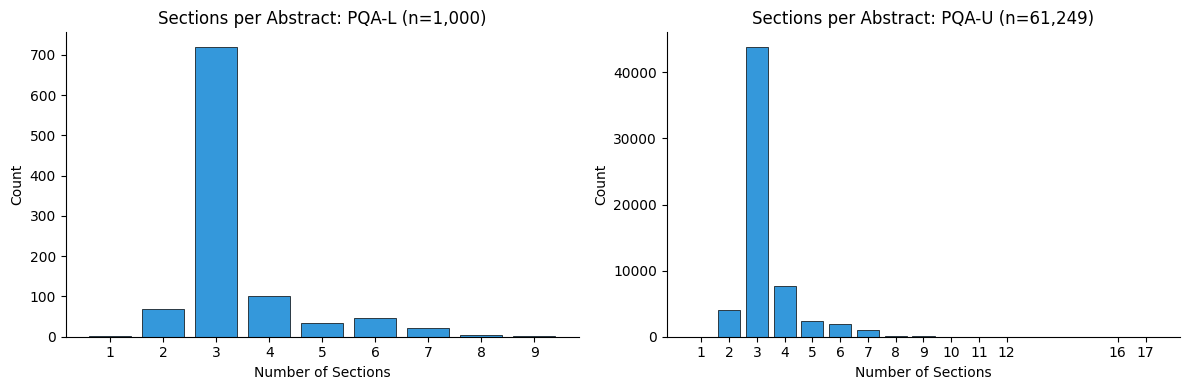

Sections per Abstract

PQA-L: mean=3.4, median=3, mode=3

PQA-U: mean=3.3, median=3, mode=3


In [ ]:
# Sections Per Abstract
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, name in [(axes[0], df_l, 'PQA-L (n=1,000)'),
                      (axes[1], df_u, 'PQA-U (n=61,249)')]:
    counts = df['num_sections'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#3498db',
           edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Number of Sections')
    ax.set_ylabel('Count')
    ax.set_title(f'Sections per Abstract: {name}')
    ax.set_xticks(counts.index)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sections_per_abstract.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Sections per Abstract")
for name, df in [('PQA-L', df_l), ('PQA-U', df_u)]:
    print(f"\n{name}: mean={df['num_sections'].mean():.1f}, "
          f"median={df['num_sections'].median():.0f}, "
          f"mode={df['num_sections'].mode().iloc[0]}")

**Observations:** The vast majority of abstracts contain 3 sections (mode=3 in both subsets: BACKGROUND-METHODS-RESULTS). The distributions are nearly identical between PQA-L and PQA-U. PQA-U has a few outliers with up to 17 sections. The shortness of the abstracts (~200 words across ~3 sections) justify concatenating sections into a single passage as retrieval strategy. Section-level chunking would produce fragments too short for meaningful semantic matching.

### 2.4 Question Type Patterns

/tmp/ipykernel_4231/4262755951.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_label, labels=label_order, patch_artist=True)


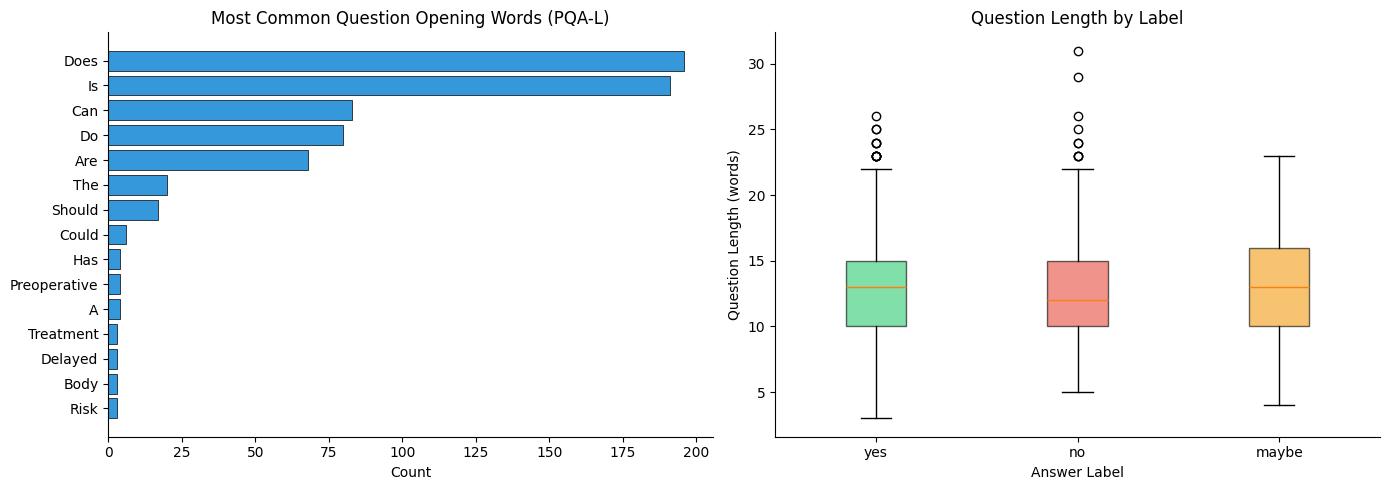

Example Questions by Opening Word

Do:
  - Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
  - Do mutations causing low HDL-C promote increased carotid intima-media thickness?

Is:
  - Is adjustment for reporting heterogeneity necessary in sleep disorders?
  - Is there still a need for living-related liver transplantation in children?

Does:
  - Does HER2 immunoreactivity provide prognostic information in locally advanced urothelial carcinoma p
  - Does diabetes mellitus influence the efficacy of FDG-PET in the diagnosis of cervical cancer?

Can:
  - Can tailored interventions increase mammography use among HMO women?
  - Can a practicing surgeon detect early lymphedema reliably?

Are:
  - Are the long-term results of the transanal pull-through equal to those of the transabdominal pull-th
  - Are reports of mechanical dysfunction in chronic oro-facial pain related to somatisation?


In [ ]:
# Analyse how questions are phrased to understand the range of query types the retrieval system must handle

# Extract first word of each question
first_words = df_l['question'].str.split().str[0].str.capitalize()
first_word_counts = first_words.value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First word frequency
axes[0].barh(first_word_counts.index[::-1], first_word_counts.values[::-1],
             color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Count')
axes[0].set_title('Most Common Question Opening Words (PQA-L)')
sns.despine(ax=axes[0])

# Question length by label
label_order = ['yes', 'no', 'maybe']
colors_box = ['#2ecc71', '#e74c3c', '#f39c12']
data_by_label = [df_l[df_l['label'] == l]['question_len'] for l in label_order]
bp = axes[1].boxplot(data_by_label, labels=label_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xlabel('Answer Label')
axes[1].set_ylabel('Question Length (words)')
axes[1].set_title('Question Length by Label')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'question_patterns.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Show example questions by type
print("Example Questions by Opening Word")
for word in ['Do', 'Is', 'Does', 'Can', 'Are']:
    examples = df_l[first_words == word]['question'].head(2).tolist()
    if examples:
        print(f"\n{word}:")
        for ex in examples:
            print(f"  - {ex[:100]}")

**Observations:** Questions mainly use yes/no structures such as "Does" (200+), "Is" (185), "Can" (80), "Do" (75), and "Are" (70) which account for the vast majority. Only a few questions start with non-interrogative words ("Preoperative", "Treatment", "Delayed"), suggesting some titles are statements phrased as implicit questions. Question length is similar across all three labels (median ~13 words), showing that the answer type is determined by the content of the evidence, not the complexity of the question. The retriever must find the right passage, not infer the answer only from the question structure.

### 2.5 Vocabulary Analysis

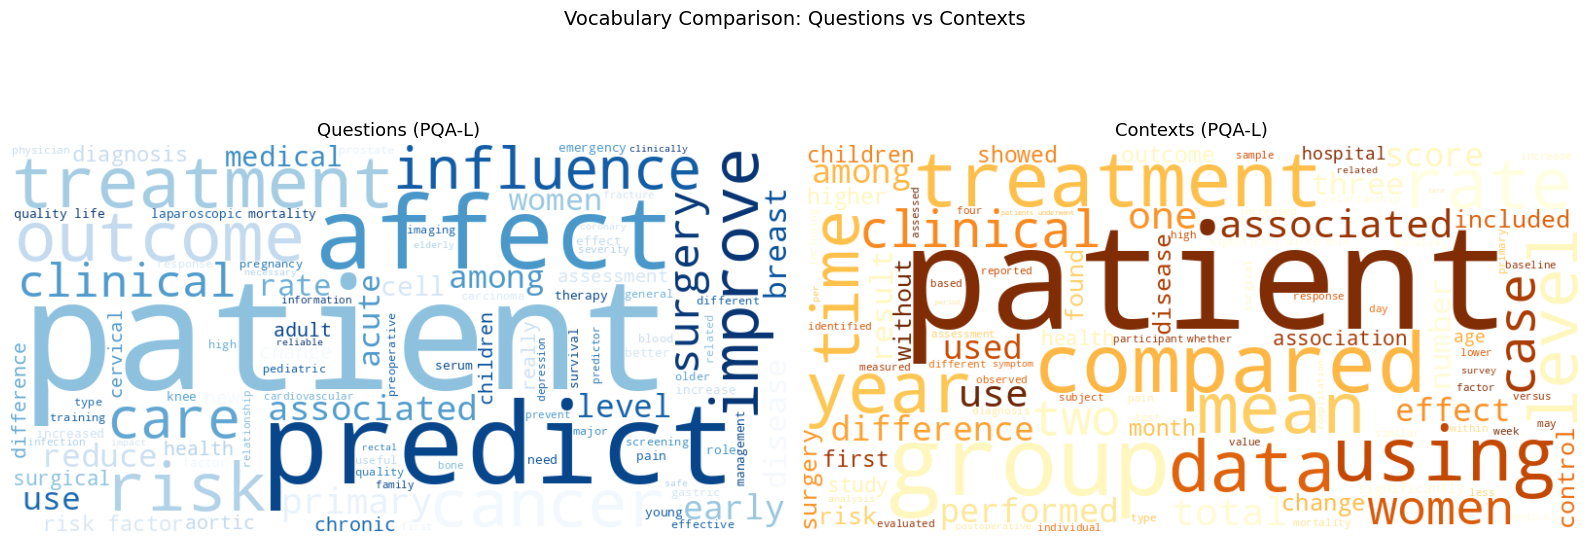

In [ ]:
# Word Clouds: Questions vs Contexts
# Compare vocabulary of questions and contexts to understand lexical overlap (relevant for BM25 retrieval) and domain-specific terminology

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text_for_wordcloud(texts):
    """Join texts, lowercase, remove stopwords"""
    combined = " ".join(texts).lower()
    words = combined.split()
    filtered = [w for w in words if w.isalpha() and w not in stop_words and len(w) > 2]
    return " ".join(filtered)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Questions word cloud
q_text = clean_text_for_wordcloud(df_l['question'].tolist())
wc_q = WordCloud(width=800, height=400, background_color='white',
                 colormap='Blues', max_words=100).generate(q_text)
axes[0].imshow(wc_q, interpolation='bilinear')
axes[0].set_title('Questions (PQA-L)', fontsize=13)
axes[0].axis('off')

# Contexts word cloud
c_text = clean_text_for_wordcloud(df_l['context'].tolist())
wc_c = WordCloud(width=800, height=400, background_color='white',
                 colormap='YlOrBr', max_words=100).generate(c_text)
axes[1].imshow(wc_c, interpolation='bilinear')
axes[1].set_title('Contexts (PQA-L)', fontsize=13)
axes[1].axis('off')

plt.suptitle('Vocabulary Comparison: Questions vs Contexts', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'wordclouds.png'),
            dpi=150, bbox_inches='tight')
plt.show()

**Observations:** Questions and contexts share the same medical vocabulary ("patient", "treatment", "cancer", "women") but differ in function. Questions use action-oriented language like "predict", "affect", "improve", "reduce", "influence", reflecting the causal nature of research questions. Contexts use empirical/methodological language like "compared", "group", "data", "rate", "assessed", "significantly", reflecting how studies report findings. This partial vocabulary overlap has a direct implication for retrieval: BM25 should perform well on shared clinical terms, but dense retrieval may better capture cases where a question asks about "improving outcomes" and the relevant abstract discusses "statistically significant differences between treatment groups."

### 2.6 MeSH Term Analysis

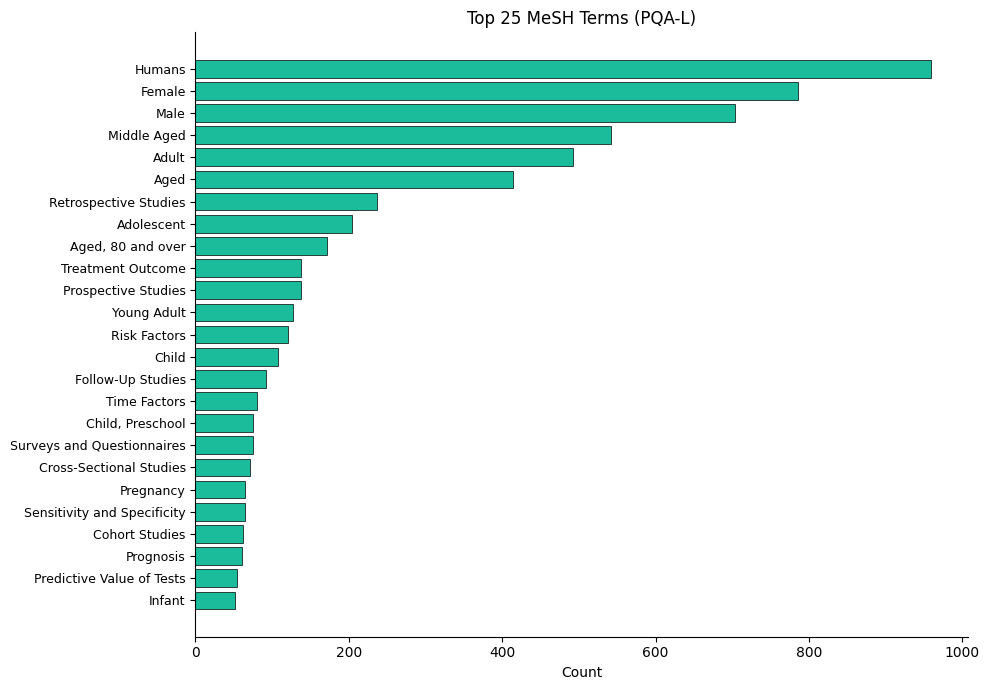

Total unique MeSH terms: 3408
Average MeSH terms per article: 14.5


In [ ]:
# MeSH (Medical Subject Headings) terms are standardised biomedical descriptors assigned to PubMed articles
# Their analysis indicates the medical domains covered by the dataset

# Flatten all MeSH terms from PQA-L
all_meshes = [m for meshes in df_l['meshes'] for m in meshes]
mesh_counts = Counter(all_meshes)

# Top 25 most common
top_meshes = mesh_counts.most_common(25)
labels_m, counts_m = zip(*top_meshes)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(labels_m))[::-1], counts_m,
        color='#1abc9c', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(labels_m))[::-1])
ax.set_yticklabels(labels_m, fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Top 25 MeSH Terms (PQA-L)')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mesh_terms.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique MeSH terms: {len(mesh_counts)}")
print(f"Average MeSH terms per article: {np.mean([len(m) for m in df_l['meshes']]):.1f}")

**Observations:** "Humans" appears in nearly all articles, with demographic descriptors (Female, Male, Middle Aged, Adult, Aged) dominating the top terms. Study design terms like "Retrospective Studies", "Prospective Studies", "Follow-Up Studies", and "Cohort Studies" reflect the empirical nature of the corpus. Clinically relevant terms like "Treatment Outcome", "Risk Factors", "Prognosis", and "Sensitivity and Specificity" indicate a strong focus on treatment efficacy and diagnostic evaluation. With 3,408 unique MeSH terms averaging 14.5 per article, the dataset spans a wide range of medical specialties. The retriever will have to handle diverse clinical domains.

### 2.7 Corpus Comparison: PQA-L vs PQA-U

In [ ]:
# Vocabulary Overlap - PQA-L vs PQA-U
vocab_l = set(" ".join(df_l['context']).lower().split())
vocab_u = set(" ".join(df_u['context']).lower().split())
overlap = vocab_l.intersection(vocab_u)

print(f"PQA-L vocabulary size:  {len(vocab_l):,} unique words")
print(f"PQA-U vocabulary size:  {len(vocab_u):,} unique words")
print(f"Shared vocabulary:      {len(overlap):,} ({len(overlap)/len(vocab_l)*100:.1f}% of PQA-L)")
print(f"PQA-L terms missing in PQA-U: {len(vocab_l - vocab_u):,} ({(len(vocab_l - vocab_u))/len(vocab_l)*100:.1f}%)")

PQA-L vocabulary size:  28,318 unique words
PQA-U vocabulary size:  442,957 unique words
Shared vocabulary:      23,728 (83.8% of PQA-L)
PQA-L terms missing in PQA-U: 4,590 (16.2%)


**Observations:** PQA-U covers 83.8% of PQA-L's vocabulary, confirming strong lexical overlap between the two subsets. The 16.2% of PQA-L terms absent from PQA-U are likely rare medical terms or proper nouns, cases where BM25 may fail to find exact matches, and dense retrieval's ability to capture semantic similarity becomes valuable.

Key takeaways for pipeline design:
- **Class imbalance** (5:1) → use macro F1 as primary metric
- **Short contexts** (~200 words) → single-passage retrieval, no chunking needed
- **Partial vocabulary overlap** → both lexical (BM25) and semantic (MedCPT) retrieval are justified
- **Diverse medical domains** (3,408 MeSH terms) → domain-specific models preferred over general-purpose

## 3. Data Preprocessing

### 3.1 Text Inspection

Before cleaning, inspect raw text for common quality issues to determine which preprocessing steps are necessary.

In [ ]:
# Text Inspection Before Preprocessing

import re

print("Sample Contexts (raw)")
for i in [0, 50, 200]:
    text = df_l['context'].iloc[i]
    print(f"\n[{i}] (len={len(text)}):")
    print(f"  {text[:200]}")

# Check for common issues across both subsets
all_contexts = df_l['context'].tolist() + df_u['context'].tolist()
all_questions = df_l['question'].tolist() + df_u['question'].tolist()

print("\nText Quality Issues (contexts)")
total = len(all_contexts)
issues_ctx = {
    'double_spaces': sum(1 for t in all_contexts if '  ' in t),
    'newlines': sum(1 for t in all_contexts if '\n' in t),
    'tabs': sum(1 for t in all_contexts if '\t' in t),
    'html_tags': sum(1 for t in all_contexts if re.search(r'<[^>]+>', t)),
    'non_ascii': sum(1 for t in all_contexts if not t.isascii()),
}
for issue, count in issues_ctx.items():
    print(f"  {issue}: {count}/{total} ({count/total*100:.1f}%)")

print(f"\nText Quality Issues (questions)")
total_q = len(all_questions)
issues_q = {
    'double_spaces': sum(1 for t in all_questions if '  ' in t),
    'non_ascii': sum(1 for t in all_questions if not t.isascii()),
    'no_question_mark': sum(1 for t in all_questions if not t.strip().endswith('?')),
}
for issue, count in issues_q.items():
    print(f"  {issue}: {count}/{total_q} ({count/total_q*100:.1f}%)")

Sample Contexts (raw)

[0] (len=1693):
  Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant co

[50] (len=900):
  One of the sites most frequently invaded by gastric cancer is the mesocolon; however, the UICC does not mention this anatomical site as an adjacent structure involved in gastric cancer. The purpose of

[200] (len=1960):
  The National Institutes of Health Stroke Scale (NIHSS) is a valid, reproducible scale that measures neurological deficit. Of 42 possible points, 7 points are directly related to measurement of languag

Text Quality Issues (contexts)
  double_spaces: 0/62249 (0.0%)
  newlines: 1/62249 (0.0%)
  tabs: 0/62249 (0.0%)
  html_tags: 2814/62249 (4.5%)
  non_ascii: 10176/62249 (16.3%)

Text Quality Issues (questions)
  double_spaces: 0/62249 (0.0%)
  non_ascii: 427/62249 (0.7%)
  no_question_mark: 0/62249 (0.0%)


In [ ]:
# Stratified Train/Test Split
# Split PQA-L into dev (500) and test (500) with stratification to preserve label proportions.
# - Dev: pipeline tuning (prompt design, top-k selection)
# - Test: final reported results

from sklearn.model_selection import train_test_split

df_dev, df_test = train_test_split(
    df_l,
    test_size=0.5,
    random_state=SEED,
    stratify=df_l['label']
)

df_dev = df_dev.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Dev set:  {len(df_dev)} instances")
print(f"Test set: {len(df_test)} instances")

print(f"\nLabel distribution:")
for name, df in [('Dev', df_dev), ('Test', df_test)]:
    counts = df['label'].value_counts()
    print(f"  {name}: yes={counts.get('yes',0)} ({counts.get('yes',0)/len(df)*100:.1f}%), "
          f"no={counts.get('no',0)} ({counts.get('no',0)/len(df)*100:.1f}%), "
          f"maybe={counts.get('maybe',0)} ({counts.get('maybe',0)/len(df)*100:.1f}%)")

Dev set:  500 instances
Test set: 500 instances

Label distribution:
  Dev: yes=276 (55.2%), no=169 (33.8%), maybe=55 (11.0%)
  Test: yes=276 (55.2%), no=169 (33.8%), maybe=55 (11.0%)


**Observations:** The raw text is generally clean and consistent with its origin from structured PubMed abstracts. The only issues are:
1. HTML tags appear in 4.5% of contexts and need removal
2. Non-ASCII characters are present in 21% of contexts (likely medical symbols and accented characters)
3. Minor double-spacing affects less than 0.2% of entries

In [ ]:
# Inspect HTML Tags and Non-ASCII Characters

# Sample HTML tags
print("Contexts with HTML tags (samples)")
html_samples = [t for t in all_contexts if re.search(r'<[^>]+>', t)][:5]
for t in html_samples:
    tags = re.findall(r'<[^>]+>', t)
    # Show the tag in its surrounding context
    for tag in tags[:3]:
        idx = t.find(tag)
        start = max(0, idx - 30)
        end = min(len(t), idx + len(tag) + 30)
        print(f"{t[start:end]}")
    print()

# Sample non-ASCII characters
print("Non-ASCII character examples")
non_ascii_chars = Counter()
for t in all_contexts:
    for ch in t:
        if not ch.isascii():
            non_ascii_chars[ch] += 1

print("Top 20 non-ASCII characters:")
for char, count in non_ascii_chars.most_common(20):
    print(f"  '{char}' (U+{ord(char):04X}): {count} occurrences")

Contexts with HTML tags (samples)
in 446 patients. 57% were aged<70 and 43% aged>70 years. 30-day mortality was
ality was 12, 4% in those aged<70 years and 22% in those>70 years (p<0.001). 1-year mor
s and 22% in those>70 years (p<0.001). 1-year mortality was 25, 15% in those aged under 70 years and 38% in those aged>70 years (p<0.001).

story of alcohol consumption (<140 g/week). Logistic regression models were used for analysis. NASH was diagnosed in 58 patients (61%; 30 f) and ASH in 37 (39%; 9 f). High-grade fibrosis (59% vs. 19%, P<0.0001) and an AST/ALT ratio>1 (54.1% vs 20.7%, P = 0.0008)

week after AC and delivered at<34 weeks. The latter were compared to women delivering>2 week after AC but>or = 34 we

ized as having normal fB-glu (<5.6 mmol/L), IFG (5.6<or =fB-glu<6.1 mmol/L), or suspected DM (SDM) (>or =6.1 mmol/L). fB-glu was no

estigate whether patients with<or =5 lesions had an improved outcome relative to patients with>5 lesions. The treatment and o
s was significantly

### 3.2 Text Preprocessing Pipeline

The text requires minimal cleaning:
1. Normalising Unicode whitespace variants to standard spaces
2. Collapse multiple spaces into one
3. Strip leading/trailing whitespace

Medical symbols, comparison operators, and accented characters are preserved as these carry domain-specific meaning relevant to both retrieval and generation

In [ ]:
# Text Preprocessing Pipeline

def preprocess_text(text):
    # Normalise Unicode whitespace (thin space, non-breaking space, etc.)
    text = re.sub(r'[\u2009\u00A0\u200A\u2005\u2002\u2003\u2004\u2006\u2007\u2008]', ' ', text)
    # Collapse multiple spaces
    text = re.sub(r' {2,}', ' ', text)
    # Strip
    text = text.strip()

    return text

# Apply to both DataFrames
df_l['context'] = df_l['context'].apply(preprocess_text)
df_l['question'] = df_l['question'].apply(preprocess_text)
df_l['long_answer'] = df_l['long_answer'].apply(preprocess_text)

df_u['context'] = df_u['context'].apply(preprocess_text)
df_u['question'] = df_u['question'].apply(preprocess_text)
df_u['long_answer'] = df_u['long_answer'].apply(preprocess_text)

# Verify cleaning
all_contexts_clean = df_l['context'].tolist() + df_u['context'].tolist()
remaining_issues = {
    'double_spaces': sum(1 for t in all_contexts_clean if '  ' in t),
    'unicode_spaces': sum(1 for t in all_contexts_clean
                         if re.search(r'[\u2009\u00A0\u200A\u2005]', t)),
}
print("Post-cleaning verification")
for issue, count in remaining_issues.items():
    print(f"  {issue}: {count}")
print(f"\nPreprocessing complete. {len(all_contexts_clean):,} passages cleaned.")

Post-cleaning verification
  double_spaces: 0
  unicode_spaces: 0

Preprocessing complete. 62,249 passages cleaned.


Additional preprocessing (lowercasing, stopword removal, tokenisation) is applied at the component level rather than globally, because each pipeline component has different requirements:
- **BM25**: lowercased, stopwords removed, whitespace tokenized
- **MedCPT**: uses its own WordPiece tokenizer internally
- **LLM generator**: receives original-cased text for natural language understanding
- **NLI model**: uses its own tokenizer internally

This approach avoids information loss from premature preprocessing and ensures that each component receives appropriately formatted input.

In [ ]:
# Saving the preprocessed DataFrames
df_l.to_pickle(os.path.join(PROCESSED_DIR, 'df_l.pkl'))
df_u.to_pickle(os.path.join(PROCESSED_DIR, 'df_u.pkl'))
print("Preprocessed DataFrames saved to Drive.")

Preprocessed DataFrames saved to Drive.


### 3.3 Train/Test Split

In [ ]:
# Stratified Train/Test Split
# Split PQA-L into dev (500) and test (500) with stratification to preserve label proportions
# - Dev: pipeline tuning (prompt design, top-k selection)
# - Test: final reported results

from sklearn.model_selection import train_test_split

df_dev, df_test = train_test_split(
    df_l,
    test_size=0.5,
    random_state=SEED,
    stratify=df_l['label']
)

df_dev = df_dev.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Dev set:  {len(df_dev)} instances")
print(f"Test set: {len(df_test)} instances")

print(f"\nLabel distribution:")
for name, df in [('Dev', df_dev), ('Test', df_test)]:
    counts = df['label'].value_counts()
    print(f"  {name}: yes={counts.get('yes',0)} ({counts.get('yes',0)/len(df)*100:.1f}%), "
          f"no={counts.get('no',0)} ({counts.get('no',0)/len(df)*100:.1f}%), "
          f"maybe={counts.get('maybe',0)} ({counts.get('maybe',0)/len(df)*100:.1f}%)")

Dev set:  500 instances
Test set: 500 instances

Label distribution:
  Dev: yes=276 (55.2%), no=169 (33.8%), maybe=55 (11.0%)
  Test: yes=276 (55.2%), no=169 (33.8%), maybe=55 (11.0%)


### 3.4 Building the Retrieval Corpus

In [ ]:
# Combine PQA-U (61,249) and PQA-L (1,000) contexts
# Adding PQA-L ensures a gold-standard passage exists

corpus_l = df_l[['pubid', 'context']].copy()
corpus_l['source'] = 'pqa_l'

corpus_u = df_u[['pubid', 'context']].copy()
corpus_u['source'] = 'pqa_u'

df_corpus = pd.concat([corpus_l, corpus_u], ignore_index=True)

corpus_texts = df_corpus['context'].tolist()
corpus_pubids = df_corpus['pubid'].tolist()
pubid_to_idx = {pid: idx for idx, pid in enumerate(corpus_pubids)}

print(f"Total retrieval corpus: {len(df_corpus):,} passages")
print(f"  From PQA-L: {len(corpus_l):,}")
print(f"  From PQA-U: {len(corpus_u):,}")

# Verify all evaluation queries have a gold passage in the corpus
dev_in_corpus = sum(1 for pid in df_dev['pubid'] if pid in pubid_to_idx)
test_in_corpus = sum(1 for pid in df_test['pubid'] if pid in pubid_to_idx)
print(f"\nGold passage coverage:")
print(f"  Dev:  {dev_in_corpus}/{len(df_dev)} ({dev_in_corpus/len(df_dev)*100:.0f}%)")
print(f"  Test: {test_in_corpus}/{len(df_test)} ({test_in_corpus/len(df_test)*100:.0f}%)")

Total retrieval corpus: 62,249 passages
  From PQA-L: 1,000
  From PQA-U: 61,249

Gold passage coverage:
  Dev:  500/500 (100%)
  Test: 500/500 (100%)


## 4. Model Development

### 4.1 Preprocessing for Retrieval

**Chunking strategy:** Each abstract is treated as a single retrieval passage. This decision is supported by the EDA:
- Abstracts average ~200 words, within the input limits of both BM25 and MedCPT (512 tokens)
- Section-level chunking would produce fragments of ~60 words, too short for meaningful semantic matching
- The 264 unique label combinations make section-level segmentation inconsistent

This is consistent with the MedRAG benchmark (Xiong et al., 2024), which indexes PubMed as one snippet per abstract.

**BM25 tokenisation:** Lowercasing and stopword removal specifically for BM25. Whitespace tokenisation is used rather than more aggressive stemming to preserve medical terminology (e.g., "fibrillation" should not be stemmed to "fibrill").

**MedCPT tokenisation:** Handled internally by the model's WordPiece tokeniser, no manual preprocessing required.

### 4.2 Retriever 1: BM25 (Sparse Retrieval)

BM25 ranks passages by term frequency and inverse document frequency. It excels at exact keyword matching, which is advantageous in biomedical text where clinical terminology is precise and distinctive.

In [ ]:
# BM25 Index: Tokenise the corpus and build a BM25 index.
# BM25-specific preprocessing: lowercase + stopword removal.

from nltk.corpus import stopwords
from rank_bm25 import BM25Okapi

stop_words = set(stopwords.words('english'))

def tokenize_for_bm25(text):
    tokens = text.lower().split()
    return [t for t in tokens if t not in stop_words and len(t) > 1]

bm25_path = os.path.join(PROCESSED_DIR, 'bm25_index.pkl')

if recovery_status.get('bm25'):
    print("BM25 index loaded from Drive.")
else:
    print("Tokenizing corpus for BM25")
    corpus_tokenized = [tokenize_for_bm25(text) for text in tqdm(corpus_texts)]

    print("Building BM25 index")
    bm25_index = BM25Okapi(corpus_tokenized)

    # Save to Drive
    with open(bm25_path, 'wb') as f:
        pickle.dump(bm25_index, f)
    recovery_status['bm25'] = True
    print(f"BM25 index built and saved. Corpus size: {len(corpus_tokenized):,}")

    # Also save tokenized corpus (needed for queries)
    with open(os.path.join(PROCESSED_DIR, 'corpus_tokenized.pkl'), 'wb') as f:
        pickle.dump(corpus_tokenized, f)

BM25 index loaded from Drive.


### 4.3 Retriever 2: MedCPT (Dense Retrieval)

MedCPT (Jin et al., 2023) is a biomedical retriever trained on 255 million PubMed user search logs using contrastive learning. It uses separate query and document encoders, making it well-suited for this task. The query encoder understands how researchers phrase questions, while the document encoder captures the semantic content of abstracts. The full corpus is encoded into dense vectors and indexed with FAISS for efficient nearest-neighbour search.

In [ ]:
# MedCPT Dense Encoding + FAISS Index
# Encode all 62k corpus passages with MedCPT's document encoder and build a FAISS index for fast retrieval

from transformers import AutoTokenizer, AutoModel

faiss_path = os.path.join(PROCESSED_DIR, 'medcpt_index.faiss')


embeddings_path = os.path.join(PROCESSED_DIR, 'corpus_embeddings.npy')

if recovery_status.get('faiss'):
    corpus_embeddings = np.load(embeddings_path)
    print(f"FAISS index and embeddings loaded from Drive.")
    print(f"Embeddings shape: {corpus_embeddings.shape}")
else:
    # Load MedCPT document encoder
    doc_tokenizer = AutoTokenizer.from_pretrained("ncbi/MedCPT-Article-Encoder")
    doc_model = AutoModel.from_pretrained("ncbi/MedCPT-Article-Encoder").to(device)
    doc_model.eval()

    # Encode in batches
    BATCH_SIZE = 64
    all_embeddings = []

    print(f"Encoding {len(corpus_texts):,} passages with MedCPT")
    for i in tqdm(range(0, len(corpus_texts), BATCH_SIZE)):
        batch = corpus_texts[i:i + BATCH_SIZE]
        encoded = doc_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = doc_model(**encoded)
            # MedCPT uses [CLS] token embedding
            embeddings = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(embeddings.cpu().numpy())

    corpus_embeddings = np.concatenate(all_embeddings, axis=0).astype('float32')
    print(f"Embeddings shape: {corpus_embeddings.shape}")

    # Build FAISS index (Inner Product MedCPT uses dot product similarity)
    dim = corpus_embeddings.shape[1]
    faiss_index = faiss.IndexFlatIP(dim)
    # Normalise for cosine similarity via inner product
    faiss.normalize_L2(corpus_embeddings)
    faiss_index.add(corpus_embeddings)

    # Save to Drive
    np.save(embeddings_path, corpus_embeddings)
    faiss.write_index(faiss_index, faiss_path)
    recovery_status['faiss'] = True

    # Free GPU memory
    del doc_model, doc_tokenizer
    torch.cuda.empty_cache()

    print(f"FAISS index built and saved. {faiss_index.ntotal:,} vectors indexed")

FAISS index and embeddings loaded from Drive.
Embeddings shape: (62249, 768)


### 4.4 Retrieval Functions

Retrieval strategies:
1. **BM25**: lexical matching via term frequency scoring
2. **MedCPT**: semantic matching via dense vector similarity
3. **Hybrid**: combines both using Reciprocal Rank Fusion (RRF), which merges ranked lists by summing inverse ranks, balancing lexical precision with semantic coverage

In [ ]:
# Retrieval Functions

# Load MedCPT query encoder (separate from document encoder)
query_tokenizer = AutoTokenizer.from_pretrained("ncbi/MedCPT-Query-Encoder")
query_model = AutoModel.from_pretrained("ncbi/MedCPT-Query-Encoder").to(device)
query_model.eval()

# Reload FAISS index if needed (after session recovery)
if 'faiss_index' not in dir():
    faiss_index = faiss.read_index(os.path.join(PROCESSED_DIR, 'medcpt_index.faiss'))


def retrieve_bm25(question, k=10):
    """Retrieve top-k passages using BM25"""
    query_tokens = tokenize_for_bm25(question)
    scores = bm25_index.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:k]
    return [(idx, scores[idx]) for idx in top_indices]


def retrieve_dense(question, k=10):
    """Retrieve top-k passages using MedCPT dense retrieval"""
    encoded = query_tokenizer(
        question,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        output = query_model(**encoded)
        query_emb = output.last_hidden_state[:, 0, :].cpu().numpy().astype('float32')

    faiss.normalize_L2(query_emb)
    scores, indices = faiss_index.search(query_emb, k)
    return [(int(idx), float(score)) for idx, score in zip(indices[0], scores[0])]


def retrieve_hybrid(question, k=10, rrf_k=60):
    """Retrieve top-k passages using Reciprocal Rank Fusion (RRF)

    RRF score: sum(1 / (rrf_k + rank)) across retrieval methods
    rrf_k=60 is the standard constant (Cormack et al., 2009)
    """
    # Get more candidates from each retriever to ensure good coverage
    bm25_results = retrieve_bm25(question, k=k*3)
    dense_results = retrieve_dense(question, k=k*3)

    # Compute RRF scores
    rrf_scores = {}
    for rank, (idx, _) in enumerate(bm25_results):
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1 / (rrf_k + rank + 1)
    for rank, (idx, _) in enumerate(dense_results):
        rrf_scores[idx] = rrf_scores.get(idx, 0) + 1 / (rrf_k + rank + 1)

    # Sort by RRF score and return top-k
    sorted_results = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return sorted_results


def get_retrieved_passages(results):
    """Convert retrieval results to passage texts and pubids"""
    passages = []
    for idx, score in results:
        passages.append({
            'index': idx,
            'pubid': corpus_pubids[idx],
            'text': corpus_texts[idx],
            'score': score
        })
    return passages

print("Retrieval functions defined.")
print(f"FAISS index: {faiss_index.ntotal:,} vectors")
print(f"Query encoder loaded on: {device}")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Retrieval functions defined.
FAISS index: 62,249 vectors
Query encoder loaded on: cuda


### 4.5 Retrieval Sanity Check

Test all 3 retrievers on sample questions from the dev set, checking if they retrieve the gold-standard passage and inspecting the quality of the results

In [ ]:
K = 5  # top-k passages to retrieve

sample_indices = [0, 10, 50]

for idx in sample_indices:
    row = df_dev.iloc[idx]
    gold_pubid = row['pubid']
    question = row['question']
    gold_label = row['label']

    print(f"Question: {question}")
    print(f"Gold label: {gold_label} | Gold PubID: {gold_pubid}")

    for name, retrieve_fn in [('BM25', retrieve_bm25),
                                ('MedCPT', retrieve_dense),
                                ('Hybrid', retrieve_hybrid)]:
        results = retrieve_fn(question, k=K)
        passages = get_retrieved_passages(results)

        # Check if gold passage is in results
        retrieved_pubids = [p['pubid'] for p in passages]
        gold_found = gold_pubid in retrieved_pubids
        gold_rank = retrieved_pubids.index(gold_pubid) + 1 if gold_found else None

        print(f"\n  [{name}] Gold found: {'✓ rank ' + str(gold_rank) if gold_found else '✗'}")
        print(f"  Top-{K} retrieved PubIDs: {retrieved_pubids}")
        print(f"  Top-1 passage (first 150 chars):")
        print(f"    {passages[0]['text'][:150]}")

    print()

Question: Informed consent for total hip arthroplasty: does a written information sheet improve recall by patients?
Gold label: yes | Gold PubID: 12484580

  [BM25] Gold found: ✓ rank 1
  Top-5 retrieved PubIDs: [12484580, 18974409, 26452387, 12672205, 17152856]
  Top-1 passage (first 150 chars):
    To ascertain whether a written information sheet is acceptable to patients and improves recall of the consent interview. Prospective randomised contro

  [MedCPT] Gold found: ✓ rank 1
  Top-5 retrieved PubIDs: [12484580, 27121872, 25337976, 21827439, 27075333]
  Top-1 passage (first 150 chars):
    To ascertain whether a written information sheet is acceptable to patients and improves recall of the consent interview. Prospective randomised contro

  [Hybrid] Gold found: ✓ rank 1
  Top-5 retrieved PubIDs: [12484580, 18974409, 21437745, 27121872, 26452387]
  Top-1 passage (first 150 chars):
    To ascertain whether a written information sheet is acceptable to patients and improves recall of 

**Observations:** All 3 retrievers successfully locate the gold passage in the top-5 across all test queries.
- **BM25** and **MedCPT** retrieve different supporting passages, confirming they capture complementary signals (lexical and semantic)
- **Hybrid (RRF)** identifies the gold passage to rank 1, demonstrating the value of a hybrid solution

The next step is to evaluate across the full dev set

### 4.6 Retrieval Evaluation

The evaluation of each retriever on the full dev set (500 queries) is done using two standard metrics:
- **Recall@k**: proportion of queries where the gold passage appears in the top-k results
- **MRR (Mean Reciprocal Rank)**: average of 1/rank of the first relevant result, indicating how high the gold passage is ranked

In [ ]:
def evaluate_retrieval(df_eval, retrieve_fn, k_values=[1, 3, 5, 10], name=""):
    """Recall@k and MRR"""
    ranks = []

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval),
                       desc=f"Evaluating {name}"):
        results = retrieve_fn(row['question'], k=max(k_values))
        retrieved_pubids = [corpus_pubids[idx] for idx, _ in results]

        if row['pubid'] in retrieved_pubids:
            rank = retrieved_pubids.index(row['pubid']) + 1
        else:
            rank = None
        ranks.append(rank)

    # Compute metrics
    metrics = {}
    for k in k_values:
        recall = sum(1 for r in ranks if r is not None and r <= k) / len(ranks)
        metrics[f'Recall@{k}'] = recall

    mrr = np.mean([1/r if r is not None else 0 for r in ranks])
    metrics['MRR'] = mrr

    return metrics, ranks

# Evaluate all 3 retrievers
retrieval_results = {}
all_ranks = {}

for name, fn in [('BM25', retrieve_bm25),
                  ('MedCPT', retrieve_dense),
                  ('Hybrid', retrieve_hybrid)]:
    metrics, ranks = evaluate_retrieval(df_dev, fn, name=name)
    retrieval_results[name] = metrics
    all_ranks[name] = ranks
    print(f"\n{name}: {metrics}")

# Display as table
results_df = pd.DataFrame(retrieval_results).T
results_df = results_df.round(4)
print("Retrieval Performance on Dev Set (n=500)")
print(results_df.to_string())

# Save results
results_df.to_csv(os.path.join(OUTPUT_DIR, 'retrieval_results_dev.csv'))

Evaluating BM25:   0%|          | 0/500 [00:00<?, ?it/s]


BM25: {'Recall@1': 0.68, 'Recall@3': 0.792, 'Recall@5': 0.84, 'Recall@10': 0.886, 'MRR': np.float64(0.7478753968253968)}


Evaluating MedCPT:   0%|          | 0/500 [00:00<?, ?it/s]


MedCPT: {'Recall@1': 0.614, 'Recall@3': 0.802, 'Recall@5': 0.854, 'Recall@10': 0.9, 'MRR': np.float64(0.717652380952381)}


Evaluating Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]


Hybrid: {'Recall@1': 0.732, 'Recall@3': 0.878, 'Recall@5': 0.922, 'Recall@10': 0.954, 'MRR': np.float64(0.8118174603174603)}
Retrieval Performance on Dev Set (n=500)
        Recall@1  Recall@3  Recall@5  Recall@10     MRR
BM25       0.680     0.792     0.840      0.886  0.7479
MedCPT     0.614     0.802     0.854      0.900  0.7177
Hybrid     0.732     0.878     0.922      0.954  0.8118


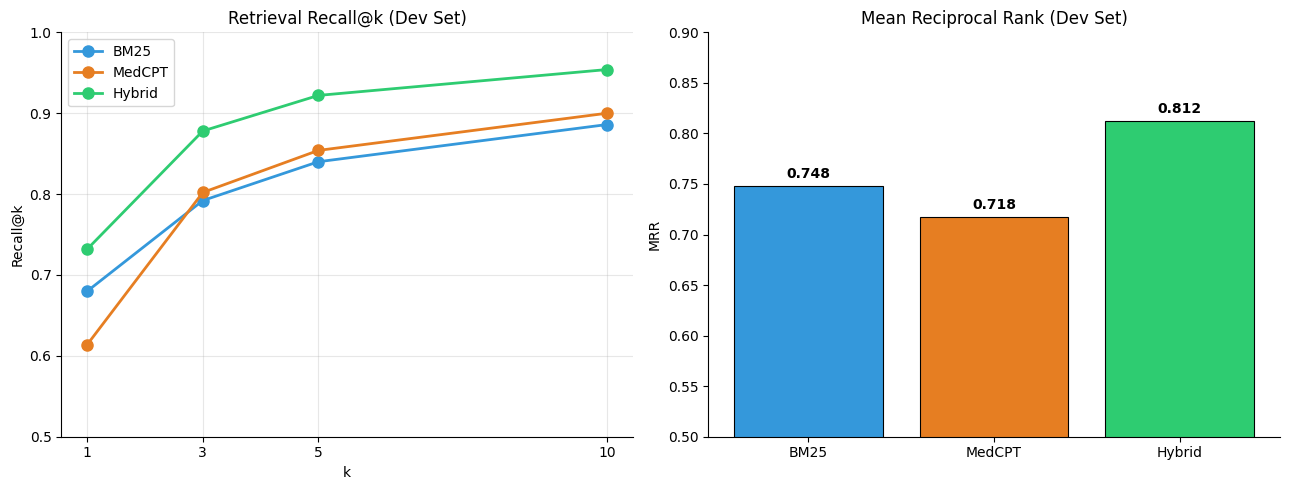

In [ ]:
# Retrieval Performance Visualisation

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Recall@k curves
k_values = [1, 3, 5, 10]
colors_ret = {'BM25': '#3498db', 'MedCPT': '#e67e22', 'Hybrid': '#2ecc71'}

for name, metrics in retrieval_results.items():
    recalls = [metrics[f'Recall@{k}'] for k in k_values]
    axes[0].plot(k_values, recalls, 'o-', label=name,
                 color=colors_ret[name], linewidth=2, markersize=8)

axes[0].set_xlabel('k')
axes[0].set_ylabel('Recall@k')
axes[0].set_title('Retrieval Recall@k (Dev Set)')
axes[0].set_xticks(k_values)
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(True, alpha=0.3)
sns.despine(ax=axes[0])

# MRR comparison
names = list(retrieval_results.keys())
mrr_values = [retrieval_results[n]['MRR'] for n in names]
bars = axes[1].bar(names, mrr_values,
                    color=[colors_ret[n] for n in names],
                    edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, mrr_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

axes[1].set_ylabel('MRR')
axes[1].set_title('Mean Reciprocal Rank (Dev Set)')
axes[1].set_ylim(0.5, 0.9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'retrieval_performance.png'),
            dpi=150, bbox_inches='tight')
plt.show()

**Observations:** The retrieval results shows complementarity between sparse and dense methods:

- **BM25** has higher Recall@1 (0.68 vs 0.614) than MedCPT, suggesting that exact lexical matching is effective when query and passage share clinical terminology (consistent with our word cloud analysis showing substantial vocabulary overlap)
- **MedCPT** performs better than BM25 at higher ranks (Recall@5: 0.854 vs 0.840; Recall@10: 0.900 vs 0.886), indicating it captures semantically relevant passages that lack exact keyword overlap
- **Hybrid RRF** outperforms both individual retrievers across all metrics (Recall@1: 0.732, Recall@10: 0.954, MRR: 0.812), confirming the value of combining lexical and semantic signals. This result aligns with findings from the MedRAG benchmark (Xiong et al., 2024) and Self-MedRAG

At k=5, the hybrid retriever finds the gold passage for 92.2% of queries, providing a strong foundation for the generation step. However, 7.8% of queries will lack their gold passage in the retrieved context. The generator must then either answer from non-gold but relevant passages or produce a less grounded response. This retrieval gap is a known challenge in RAG systems.

### 4.7 Generator: LLM-Based Answer Generation

Claude Sonnet is used to generate answers conditioned on retrieved passages. Prompt design:
1. Constrain the model to reason only from the provided evidence
2. Produce a structured output with a yes/no/maybe classification and supporting reasoning
3. Explicitly flag when the evidence is insufficient.

If the model ignores the context and relies on parametric knowledge, the NLI-based checker should detect the discrepancy.

In [ ]:
# Generator: Prompt Design and API Integration

SYSTEM_PROMPT = """You are a biomedical research assistant. Your task is to
answer medical research questions based ONLY on the provided context passages.

Rules:
1. Base your answer strictly on the evidence in the provided passages
2. Do not use any external knowledge beyond what is in the passages
3. If the passages do not contain sufficient evidence, say "maybe"
4. Provide brief reasoning that references specific findings from the passages

Respond in exactly this format:
ANSWER: [yes/no/maybe]
REASONING: [Your reasoning based on the passages, 2-3 sentences]"""


def build_prompt(question, passages):
    """Construct the user prompt with retrieved passages"""
    context_block = ""
    for i, p in enumerate(passages, 1):
        context_block += f"\nPassage {i}\n{p['text']}\n"

    user_prompt = f"""Context passages:
{context_block}
Question: {question}

Based ONLY on the above passages, answer the question"""

    return user_prompt


def parse_response(response_text):
    """Extract answer label and reasoning from LLM response"""
    answer = None
    reasoning = None

    for line in response_text.strip().split('\n'):
        line_clean = line.strip()
        if line_clean.upper().startswith('ANSWER:'):
            raw = line_clean.split(':', 1)[1].strip().lower()
            # Normalise to yes/no/maybe
            if 'yes' in raw:
                answer = 'yes'
            elif 'no' in raw and 'maybe' not in raw:
                answer = 'no'
            elif 'maybe' in raw:
                answer = 'maybe'
        elif line_clean.upper().startswith('REASONING:'):
            reasoning = line_clean.split(':', 1)[1].strip()

    # If reasoning spans multiple lines after REASONING:
    if reasoning and 'REASONING:' in response_text:
        reasoning = response_text.split('REASONING:', 1)[1].strip()

    return answer, reasoning


def generate_answer(question, passages, max_retries=3):
    """Call Claude API with retrieved passages and return parsed answer"""
    user_prompt = build_prompt(question, passages)

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model="claude-sonnet-4-20250514",
                max_tokens=300,
                messages=[
                    {"role": "user", "content": user_prompt}
                ],
                system=SYSTEM_PROMPT,
                temperature=0  # For deterministic output
            )
            response_text = response.content[0].text
            answer, reasoning = parse_response(response_text)

            if answer is not None:
                return {
                    'answer': answer,
                    'reasoning': reasoning,
                    'raw_response': response_text
                }
            else:
                print(f"  Parse failed (attempt {attempt+1}), retrying")

        except Exception as e:
            print(f"  API error (attempt {attempt+1}): {e}")
            time.sleep(2 ** attempt)  # Exponential backoff

    # Fallback if all retries fail
    return {'answer': None, 'reasoning': None, 'raw_response': None}


# Test on one example
test_row = df_dev.iloc[0]
test_results = retrieve_hybrid(test_row['question'], k=5)
test_passages = get_retrieved_passages(test_results)
test_output = generate_answer(test_row['question'], test_passages)

print(f"Question: {test_row['question']}")
print(f"Gold label: {test_row['label']}")
print(f"\nGenerated answer: {test_output['answer']}")
print(f"Reasoning: {test_output['reasoning']}")
print(f"\nRaw response:\n{test_output['raw_response']}")

  API error (attempt 1): Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZiGdGsgmw4eULbxd4dAP'}
  API error (attempt 2): Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZiGdN2FUe6x9G35DwjRT'}
  API error (attempt 3): Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZiGdWzW6TE1BETcG2pDw'}
Question: Informed consent for total hip arthroplasty: does a written information sheet improve recall by patients?
Gold label: yes

Generated

**Design choices and observations:**
- **Temperature 0** ensures reproducible outputs across runs
- **max_tokens=300** keeps responses concise and focused on the evidence
- **Exponential backoff** with 3 retries handles teh API rate limits
- **Structured output format** (ANSWER/REASONING) permits reliable parsing for automated evaluation
- The system prompt explicitly instructs the model to answer "maybe" when evidence is insufficient
- The test output has a strong grounding behaviour. The reasoning references specific findings ("48% correct answers vs 38%") from the retrieved passage without relying on general knowledge

### 4.8 Full Generation Pipeline

Run the complete retrieve-then-generate pipeline on the dev set for the retrieval strategies.

In [ ]:
K = 5  # Number of passages to retrieve

retrievers = {
    'bm25': retrieve_bm25,
    'dense': retrieve_dense,
    'hybrid': retrieve_hybrid
}

for ret_name, retrieve_fn in retrievers.items():
    results_path = os.path.join(PROCESSED_DIR, f'results_{ret_name}.pkl')

    if recovery_status.get(f'results_{ret_name}'):
        print(f"[{ret_name}] Results already saved skipping.")
        continue

    print(f"Running pipeline with {ret_name} retriever")

    results = []
    for i, row in tqdm(df_dev.iterrows(), total=len(df_dev),
                       desc=f"Generating ({ret_name})"):
        # Retrieve
        retrieved = retrieve_fn(row['question'], k=K)
        passages = get_retrieved_passages(retrieved)

        # Generate
        output = generate_answer(row['question'], passages)

        # Store everything for evaluation
        results.append({
            'pubid': row['pubid'],
            'question': row['question'],
            'gold_label': row['label'],
            'gold_context': row['context'],
            'gold_long_answer': row['long_answer'],
            'predicted_label': output['answer'],
            'reasoning': output['reasoning'],
            'raw_response': output['raw_response'],
            'retrieved_pubids': [p['pubid'] for p in passages],
            'retrieved_texts': [p['text'] for p in passages],
            'gold_in_retrieved': row['pubid'] in [p['pubid'] for p in passages],
        })

        # Save incrementally every 50 queries
        if (i + 1) % 50 == 0:
            with open(results_path, 'wb') as f:
                pickle.dump(results, f)
            print(f"  Checkpoint saved at {i+1}/{len(df_dev)}")

    # Final save
    with open(results_path, 'wb') as f:
        pickle.dump(results, f)
    recovery_status[f'results_{ret_name}'] = True
    print(f"[{ret_name}] Complete. {len(results)} results saved.")

print("\nAll pipelines complete.")

[bm25] Results already saved skipping.
[dense] Results already saved skipping.
[hybrid] Results already saved skipping.

All pipelines complete.


In [ ]:
# Load results and check for failures
pipeline_results = {}
for ret_name in ['bm25', 'dense', 'hybrid']:
    results_path = os.path.join(PROCESSED_DIR, f'results_{ret_name}.pkl')
    with open(results_path, 'rb') as f:
        pipeline_results[ret_name] = pickle.load(f)

for ret_name, results in pipeline_results.items():
    failed = sum(1 for r in results if r['predicted_label'] is None)
    print(f"[{ret_name}] Total: {len(results)}, Failed: {failed}")
    if failed > 0:
        failed_indices = [i for i, r in enumerate(results) if r['predicted_label'] is None]
        print(f"  Failed indices: {failed_indices}")

[bm25] Total: 500, Failed: 0
[dense] Total: 500, Failed: 0
[hybrid] Total: 500, Failed: 0


In [ ]:
# Rerun the single failed hybrid query
failed_idx = 477
row = df_dev.iloc[failed_idx]
print(f"Retrying: {row['question'][:80]}")

retrieved = retrieve_hybrid(row['question'], k=5)
passages = get_retrieved_passages(retrieved)
output = generate_answer(row['question'], passages)

print(f"Answer: {output['answer']}")
print(f"Reasoning: {output['reasoning']}")

if output['answer'] is not None:
    # Update the result
    pipeline_results['hybrid'][failed_idx].update({
        'predicted_label': output['answer'],
        'reasoning': output['reasoning'],
        'raw_response': output['raw_response'],
        'retrieved_pubids': [p['pubid'] for p in passages],
        'retrieved_texts': [p['text'] for p in passages],
        'gold_in_retrieved': row['pubid'] in [p['pubid'] for p in passages],
    })

    # Save updated results
    results_path = os.path.join(PROCESSED_DIR, 'results_hybrid.pkl')
    with open(results_path, 'wb') as f:
        pickle.dump(pipeline_results['hybrid'], f)
    print("Fixed and saved")
else:
    print("Still failing will exclude from evaluation")

Retrying: Is oral endotracheal intubation efficacy impaired in the helicopter environment?
  API error (attempt 1): Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZiGhuC6YpThJmYaYDv77'}
  API error (attempt 2): Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZiGhyz5MAvMAgpnE3wCy'}
  API error (attempt 3): Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CZiGi8ypExtgyFwyEKWRs'}
Answer: None
Reasoning: None
Still failing will exc

## 5. Evaluation and Results

### 5.1 QA Accuracy

Evaluate the predicted yes/no/maybe labels against the gold standard using accuracy, macro F1 (primary metric due to class imbalance), and per-class precision/recall, including a majority-class baseline (always predict "yes") for context

In [ ]:
def evaluate_qa(results, name=""):
    """Compute QA metrics for a set of pipeline results"""
    gold = [r['gold_label'] for r in results]
    pred = [r['predicted_label'] for r in results]

    metrics = {
        'Accuracy': accuracy_score(gold, pred),
        'Macro F1': f1_score(gold, pred, average='macro'),
        'Macro Precision': precision_score(gold, pred, average='macro'),
        'Macro Recall': recall_score(gold, pred, average='macro'),
    }
    return metrics

# Majority baseline
majority_baseline = {
    'Accuracy': df_dev['label'].value_counts(normalize=True).max(),
    'Macro F1': f1_score(df_dev['label'], ['yes'] * len(df_dev), average='macro'),
    'Macro Precision': precision_score(df_dev['label'], ['yes'] * len(df_dev),
                                        average='macro', zero_division=0),
    'Macro Recall': recall_score(df_dev['label'], ['yes'] * len(df_dev), average='macro'),
}

# Evaluate all retrievers
qa_results = {'Majority Baseline': majority_baseline}
for ret_name, results in pipeline_results.items():
    qa_results[ret_name.upper()] = evaluate_qa(results, name=ret_name)

# Display results table
qa_df = pd.DataFrame(qa_results).T.round(4)
print("QA Performance on Dev Set (n=500)")
print(qa_df.to_string())
qa_df.to_csv(os.path.join(OUTPUT_DIR, 'qa_results_dev.csv'))

# Per-class breakdown for hybrid (best retriever)
labels_order = ['yes', 'no', 'maybe']
gold_hybrid = [r['gold_label'] for r in pipeline_results['hybrid']]
pred_hybrid = [r['predicted_label'] for r in pipeline_results['hybrid']]

print("Per-Class Report: Hybrid retriever")
print(f"\nGold distribution: {Counter(gold_hybrid)}")
print(f"Pred distribution: {Counter(pred_hybrid)}")
print()
print(classification_report(gold_hybrid, pred_hybrid,
                            labels=labels_order,
                            target_names=labels_order))

# Confusion matrix
cm = confusion_matrix(gold_hybrid, pred_hybrid, labels=labels_order)
print("Confusion Matrix (rows=gold, cols=predicted):")
print(f"{'':>10} pred_yes  pred_no  pred_maybe")
for i, label in enumerate(labels_order):
    print(f"{label:>10} {cm[i][0]:>8} {cm[i][1]:>8} {cm[i][2]:>8}")

QA Performance on Dev Set (n=500)
                   Accuracy  Macro F1  Macro Precision  Macro Recall
Majority Baseline     0.552    0.2371           0.1840        0.3333
BM25                  0.642    0.5636           0.6060        0.5717
DENSE                 0.654    0.5663           0.6065        0.5718
HYBRID                0.684    0.5808           0.6088        0.5807
Per-Class Report: Hybrid retriever

Gold distribution: Counter({'yes': 276, 'no': 169, 'maybe': 55})
Pred distribution: Counter({'yes': 271, 'no': 124, 'maybe': 105})

              precision    recall  f1-score   support

         yes       0.81      0.79      0.80       276
          no       0.85      0.62      0.72       169
       maybe       0.17      0.33      0.23        55

    accuracy                           0.68       500
   macro avg       0.61      0.58      0.58       500
weighted avg       0.75      0.68      0.71       500

Confusion Matrix (rows=gold, cols=predicted):
           pred_yes  pred_

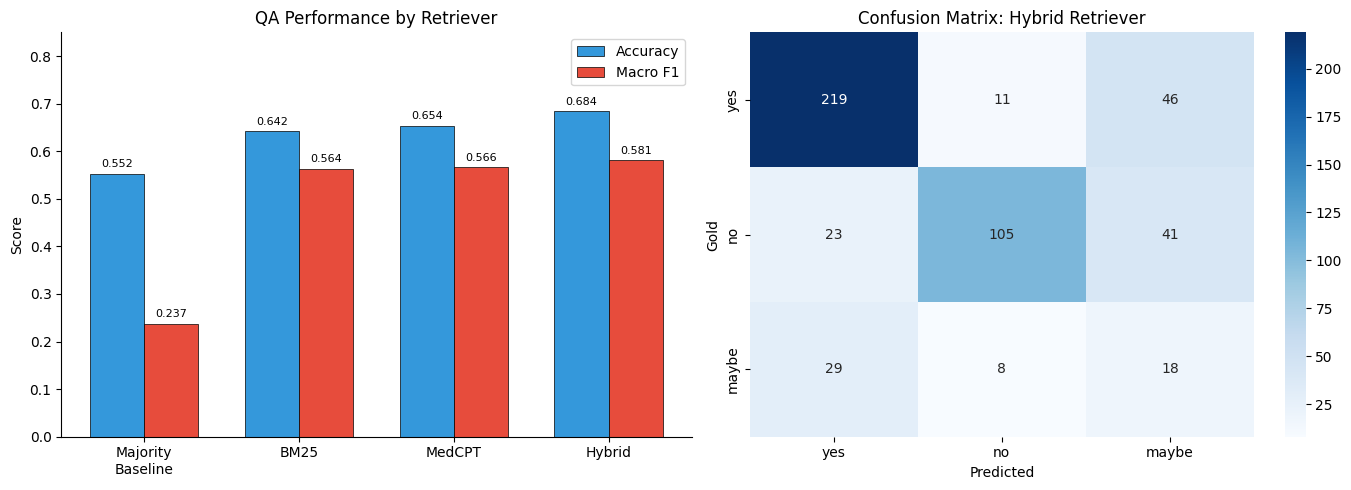

In [ ]:
# QA performance visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Accuracy and Macro
methods = ['Majority\nBaseline', 'BM25', 'MedCPT', 'Hybrid']
accuracy_vals = [qa_results[k]['Accuracy'] for k in ['Majority Baseline', 'BM25', 'DENSE', 'HYBRID']]
f1_vals = [qa_results[k]['Macro F1'] for k in ['Majority Baseline', 'BM25', 'DENSE', 'HYBRID']]

x = np.arange(len(methods))
width = 0.35
bars1 = axes[0].bar(x - width/2, accuracy_vals, width, label='Accuracy',
                     color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, f1_vals, width, label='Macro F1',
                     color='#e74c3c', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel('Score')
axes[0].set_title('QA Performance by Retriever')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].set_ylim(0, 0.85)
sns.despine(ax=axes[0])

# Confusion matrix heatmap for hybrid
labels_order = ['yes', 'no', 'maybe']
cm = confusion_matrix(gold_hybrid, pred_hybrid, labels=labels_order)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=labels_order, yticklabels=labels_order)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Gold')
axes[1].set_title('Confusion Matrix: Hybrid Retriever')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'qa_performance.png'),
            dpi=150, bbox_inches='tight')
plt.show()

**Observations:** All three RAG pipelines outperform the majority baseline (55.2% accuracy, 0.237 macro F1), confirming that retrieval-augmented generation adds value. The hybrid retriever achieves the best performance (68.4% accuracy, 0.581 macro F1), consistent with its superior retrieval quality.

Per-class analysis reveals a clear difficulty gradient:
- **Yes** (precision 0.81, recall 0.79): the model handles the majority class well
- **No** (precision 0.85, recall 0.62): high precision but lower recall meaning that the model is conservative about predicting "no", often defaulting to "yes" or "maybe" instead
- **Maybe** (precision 0.17, recall 0.33): hardest class. The model over-predicts "maybe" (105 predictions vs 55 gold), producing many false positives. This is porbably because of the prompt design, which instructs the model to answer "maybe" when evidence is insufficient

The confusion matrix shows that the most common errors are yes→maybe (46 cases) and no→maybe (41 cases) so the model struggles to commit to a definitive answer when the retrieved context is ambiguous or when non-gold passages introduce different signals

### 5.2 Faithfulness Evaluation

Accuracy alone is insufficient for medical QA because a correct answer derived from hallucinated reasoning can be very dangerous in clinical settings. Faithfulness is evaluated using a biomedical NLI model (PubMedBERT fine-tuned on MNLI and MedNLI) to assess whether each generated answer is entailed by the retrieved context. This measures if the model's reasoning is grounded in the evidence or relies on parametric knowledge.

For each (retrieved_context, generated_reasoning) pair, the NLI model classifies the relationship as:
- **Entailment**: the reasoning is supported by the context (faithful)
- **Contradiction**: the reasoning conflicts with the context
- **Neutral**: the reasoning is neither supported nor contradicted

In [ ]:
# Load biomedical NLI model
nli_tokenizer = AutoTokenizer.from_pretrained("pritamdeka/PubMedBERT-MNLI-MedNLI")
nli_model = AutoModelForSequenceClassification.from_pretrained(
    "pritamdeka/PubMedBERT-MNLI-MedNLI", num_labels=3
).to(device)
nli_model.eval()

# Label mapping for this model
NLI_LABELS = {0: 'contradiction', 1: 'entailment', 2: 'neutral'}

def evaluate_faithfulness(context, reasoning, max_length=512):
    """Score if reasoning is entailed by teh context using biomedical NLI"""
    if not reasoning or not context:
        return {'label': 'neutral', 'scores': {}, 'entailment_score': 0.0}

    encoded = nli_tokenizer(
        context,
        reasoning,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = nli_model(**encoded)
        probs = torch.softmax(outputs.logits, dim=1)[0]

    scores = {NLI_LABELS[i]: probs[i].item() for i in range(3)}
    predicted_label = NLI_LABELS[probs.argmax().item()]

    return {
        'label': predicted_label,
        'scores': scores,
        'entailment_score': scores['entailment']
    }


# Run faithfulness evaluation on all pipeline results
for ret_name, results in pipeline_results.items():
    print(f"\nEvaluating faithfulness: {ret_name}")
    for r in tqdm(results, desc=f"NLI ({ret_name})"):
        # Combine retrieved passages as the premise
        retrieved_context = " ".join(r['retrieved_texts'][:3])  # Top-3 for NLI input length
        reasoning = r.get('reasoning', '')

        faith = evaluate_faithfulness(retrieved_context, reasoning)
        r['faithfulness_label'] = faith['label']
        r['faithfulness_scores'] = faith['scores']
        r['entailment_score'] = faith['entailment_score']

    # Save updated results
    results_path = os.path.join(PROCESSED_DIR, f'results_{ret_name}.pkl')
    with open(results_path, 'wb') as f:
        pickle.dump(results, f)

print("\nFaithfulness evaluation completed")

config.json:   0%|          | 0.00/911 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/415 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...


Evaluating faithfulness: dense


NLI (dense):   0%|          | 0/500 [00:00<?, ?it/s]


Evaluating faithfulness: hybrid


NLI (hybrid):   0%|          | 0/500 [00:00<?, ?it/s]


Faithfulness evaluation completed


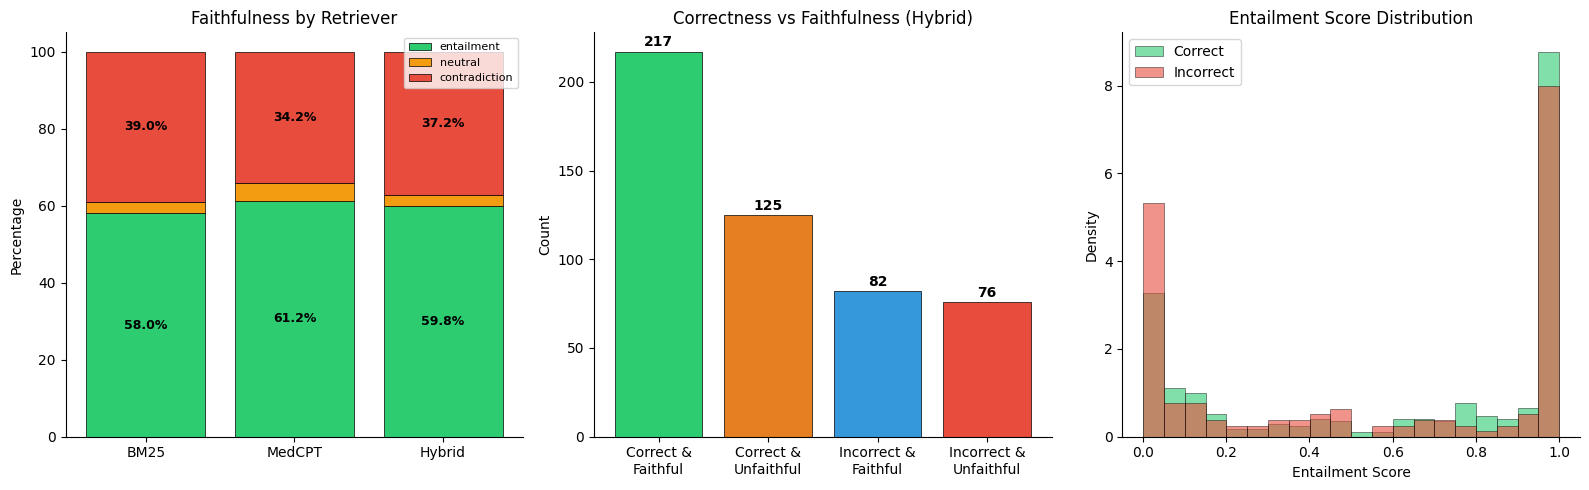

Faithfulness Summary
    bm25: entailment=58.0%, mean_score=0.581, contradiction=195
   dense: entailment=61.2%, mean_score=0.600, contradiction=171
  hybrid: entailment=59.8%, mean_score=0.600, contradiction=186


In [ ]:
# Faithfulness Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_faith = {'entailment': '#2ecc71', 'neutral': '#f39c12', 'contradiction': '#e74c3c'}
faith_labels_order = ['entailment', 'neutral', 'contradiction']

# Panel 1: Faithfulness distribution by retriever
for i, (ret_name, results) in enumerate(pipeline_results.items()):
    faith_counts = Counter(r['faithfulness_label'] for r in results)
    total = len(results)
    pcts = [faith_counts.get(l, 0) / total * 100 for l in faith_labels_order]

    bottom = 0
    for label, pct in zip(faith_labels_order, pcts):
        axes[0].bar(i, pct, bottom=bottom, color=colors_faith[label],
                    edgecolor='black', linewidth=0.5, label=label if i == 0 else "")
        if pct > 5:
            axes[0].text(i, bottom + pct/2, f'{pct:.1f}%',
                        ha='center', va='center', fontsize=9, fontweight='bold')
        bottom += pct

axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['BM25', 'MedCPT', 'Hybrid'])
axes[0].set_ylabel('Percentage')
axes[0].set_title('Faithfulness by Retriever')
axes[0].legend(loc='upper right', fontsize=8)
sns.despine(ax=axes[0])

# Panel 2: Faithfulness vs Correctness (Hybrid)
hybrid_results = pipeline_results['hybrid']
categories = {
    'Correct &\nFaithful': sum(1 for r in hybrid_results
                               if r['predicted_label'] == r['gold_label']
                               and r['faithfulness_label'] == 'entailment'),
    'Correct &\nUnfaithful': sum(1 for r in hybrid_results
                                  if r['predicted_label'] == r['gold_label']
                                  and r['faithfulness_label'] != 'entailment'),
    'Incorrect &\nFaithful': sum(1 for r in hybrid_results
                                  if r['predicted_label'] != r['gold_label']
                                  and r['faithfulness_label'] == 'entailment'),
    'Incorrect &\nUnfaithful': sum(1 for r in hybrid_results
                                    if r['predicted_label'] != r['gold_label']
                                    and r['faithfulness_label'] != 'entailment'),
}

cat_colors = ['#2ecc71', '#e67e22', '#3498db', '#e74c3c']
bars = axes[1].bar(categories.keys(), categories.values(),
                    color=cat_colors, edgecolor='black', linewidth=0.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(bar.get_height())), ha='center', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_title('Correctness vs Faithfulness (Hybrid)')
sns.despine(ax=axes[1])

# Panel 3: Entailment score distribution by correctness
correct_scores = [r['entailment_score'] for r in hybrid_results
                  if r['predicted_label'] == r['gold_label']]
incorrect_scores = [r['entailment_score'] for r in hybrid_results
                    if r['predicted_label'] != r['gold_label']]

axes[2].hist(correct_scores, bins=20, alpha=0.6, label='Correct', color='#2ecc71',
             edgecolor='black', linewidth=0.5, density=True)
axes[2].hist(incorrect_scores, bins=20, alpha=0.6, label='Incorrect', color='#e74c3c',
             edgecolor='black', linewidth=0.5, density=True)
axes[2].set_xlabel('Entailment Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Entailment Score Distribution')
axes[2].legend()
sns.despine(ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'faithfulness_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("Faithfulness Summary")
for ret_name, results in pipeline_results.items():
    faith_counts = Counter(r['faithfulness_label'] for r in results)
    total = len(results)
    ent_rate = faith_counts.get('entailment', 0) / total * 100
    mean_score = np.mean([r['entailment_score'] for r in results])
    print(f"{ret_name:>8}: entailment={ent_rate:.1f}%, "
          f"mean_score={mean_score:.3f}, "
          f"contradiction={faith_counts.get('contradiction', 0)}")

**Observations:**

**Overall faithfulness rates are moderate (~58-61%).** Across all retrievers, only about 60% of generated answers are classified as derived by the retrieved context. The contradiction rate is high (34-39%), suggesting the model frequently generates reasoning that conflicts with or goes beyond the retrieved evidence. MedCPT achieves the highest entailment rate (61.2%) and lowest contradiction rate (34.2%), possibly because its semantically matched passages are more coherent with each other, making it easier for the generator to stay grounded.

**The correctness-faithfulness matrix (Panel 2) is the most important finding.** Of the 342 correct predictions by the hybrid retriever:
- 217 (63%) are both correct and faithful
- 125 (37%) are correct but unfaithful, the model got the right answer, but for reasons not related to the retrieved evidence, likely relying on parametric medical knowledge

This 37% "correct but unfaithful" rate is a concern for clinical deployment. A system that produces right answers for wrong reasons is unreliable because it may fail unpredictably when encountering questions outside its training distribution.

Of the 158 incorrect predictions:
- 82 are faithful but incorrect meaning that the model faithfully followed misleading or insufficient evidence
- 76 are both unfaithful and incorrect so the model hallucinated and got it wrong

**Entailment score distributions (Panel 3)** show that correct answers cluster at high entailment scores (>0.8) while incorrect answers cluster at low scores (0.2), suggesting entailment score could serve as a confidence indicator that answers with low entailment scores are more likely to be wrong.

### 5.3 Error Analysis

Failure modes examination to understand when and why the pipeline produces incorrect or unfaithful answers, and if retrieval quality is a contributing factor

In [ ]:
hybrid = pipeline_results['hybrid']

# Analysis 1: Error rate by label
print("Error Rate by Gold Label")
for label in ['yes', 'no', 'maybe']:
    subset = [r for r in hybrid if r['gold_label'] == label]
    errors = sum(1 for r in subset if r['predicted_label'] != r['gold_label'])
    faithful = sum(1 for r in subset if r['faithfulness_label'] == 'entailment')
    print(f"  {label:>5}: {errors}/{len(subset)} incorrect ({errors/len(subset)*100:.1f}%), "
          f"faithfulness={faithful/len(subset)*100:.1f}%")

# Analysis 2: Impact of retrieval on accuracy
print("Impact of Gold Passage Retrieval on Accuracy")
gold_found = [r for r in hybrid if r['gold_in_retrieved']]
gold_missed = [r for r in hybrid if not r['gold_in_retrieved']]

acc_found = sum(1 for r in gold_found if r['predicted_label'] == r['gold_label']) / len(gold_found)
acc_missed = sum(1 for r in gold_missed if r['predicted_label'] == r['gold_label']) / len(gold_missed) if gold_missed else 0

faith_found = sum(1 for r in gold_found if r['faithfulness_label'] == 'entailment') / len(gold_found)
faith_missed = sum(1 for r in gold_missed if r['faithfulness_label'] == 'entailment') / len(gold_missed) if gold_missed else 0

print(f"  Gold passage retrieved ({len(gold_found)}):  accuracy={acc_found:.3f}, faithfulness={faith_found:.3f}")
print(f"  Gold passage missed   ({len(gold_missed)}):  accuracy={acc_missed:.3f}, faithfulness={faith_missed:.3f}")

# Analysis 3: Common error patterns
print("Error Pattern Examples (Hybrid)")

# Correct but unfaithful
print("\nCorrect but UNFAITHFUL (right answer, wrong reasoning)")
correct_unfaithful = [r for r in hybrid
                      if r['predicted_label'] == r['gold_label']
                      and r['faithfulness_label'] == 'contradiction']
for r in correct_unfaithful[:2]:
    print(f"\n  Q: {r['question'][:100]}")
    print(f"  Gold: {r['gold_label']} | Pred: {r['predicted_label']}")
    print(f"  Reasoning: {r['reasoning'][:150]}")
    print(f"  Entailment score: {r['entailment_score']:.3f}")

# Faithful but incorrect
print("\n Faithful but Incorrect (grounded reasoning, wrong answer)")
faithful_incorrect = [r for r in hybrid
                      if r['predicted_label'] != r['gold_label']
                      and r['faithfulness_label'] == 'entailment']
for r in faithful_incorrect[:2]:
    print(f"\n  Q: {r['question'][:100]}")
    print(f"  Gold: {r['gold_label']} | Pred: {r['predicted_label']}")
    print(f"  Reasoning: {r['reasoning'][:150]}")
    print(f"  Gold in retrieved: {r['gold_in_retrieved']}")

# Maybe misclassifications
print("\n 'Maybe' Prediction Errors")
maybe_errors = [r for r in hybrid
                if r['predicted_label'] == 'maybe'
                and r['gold_label'] != 'maybe']
print(f"  Total 'maybe' false positives: {len(maybe_errors)}")
print(f"  Actual labels: {Counter(r['gold_label'] for r in maybe_errors)}")
print(f"  Gold passage retrieved: {sum(1 for r in maybe_errors if r['gold_in_retrieved'])}/{len(maybe_errors)}")

Error Rate by Gold Label
    yes: 57/276 incorrect (20.7%), faithfulness=63.4%
     no: 64/169 incorrect (37.9%), faithfulness=54.4%
  maybe: 37/55 incorrect (67.3%), faithfulness=58.2%
Impact of Gold Passage Retrieval on Accuracy
  Gold passage retrieved (463):  accuracy=0.724, faithfulness=0.620
  Gold passage missed   (37):  accuracy=0.189, faithfulness=0.324
Error Pattern Examples (Hybrid)

Correct but UNFAITHFUL (right answer, wrong reasoning)

  Q: Informed consent for total hip arthroplasty: does a written information sheet improve recall by pati
  Gold: yes | Pred: yes
  Reasoning: Passage 1 directly addresses this question with a prospective randomized controlled study of 126 patients undergoing total hip arthroplasty. The study
  Entailment score: 0.097

  Q: Are acceptance rates of a national preventive home visit programme for older people socially imbalan
  Gold: yes | Pred: yes
  Reasoning: Passage 1 provides direct evidence that acceptance rates of preventive home visits

**Observations:**

**Error rate scales inversely with label certainty:** "Yes" questions (20.7% error) are easiest, "no" (37.9%) harder, and "maybe" (67.3%) hardest. This aligns with the task's nature as "maybe" requires recognising that evidence is inconclusive

**Retrieval quality is a strong predictor of success:** When the gold passage is retrieved, accuracy is 72.4%; when missed, it drops to 18.9%. Faithfulness follows the same pattern (62.0% vs 32.4%). TThis means retrieval is the differentiator, improving the retriever has a direct downstream impact on both accuracy and groundedness.

**"Correct but unfaithful" cases warrant caution:** The examples show answers with very low entailment scores (0.097, 0.001) despite being correct, the reasoning appears well-grounded to a human reader but the NLI model flags it as not entailed. But this may reflect a limitation of the NLI model: when the premise (retrieved context) is long and the hypothesis (reasoning) references specific details, the 512-token truncation may cut relevant supporting evidence. This is a known challenge with NLI-based faithfulness evaluation.

**"Faithful but incorrect" cases reveal a "maybe" problem:** Both examples show the model predicting "yes" when the gold label is "maybe" hence the model finds supporting evidence and commits to an affirmative answer, whereas the human annotators judged the evidence as inconclusive. Determining when evidence is *sufficient* for a definitive answer versus merely *suggestive* requires calibrated uncertainty, which is challenging for LLMs.

**"Maybe" over-prediction is the dominant error mode:** Of 87 false "maybe" predictions, 46 were actually "yes" and 41 were "no". The model defaults to "maybe" roughly equally across both classes, suggesting it uses "maybe" as a hedge when the retrieved context is noisy or conflicting rather than genuinely ambiguous.

### 5.4 Results Summary

In [ ]:
summary_data = []
for ret_name, results in pipeline_results.items():
    n = len(results)
    correct = sum(1 for r in results if r['predicted_label'] == r['gold_label'])
    faithful = sum(1 for r in results if r['faithfulness_label'] == 'entailment')
    correct_faithful = sum(1 for r in results
                          if r['predicted_label'] == r['gold_label']
                          and r['faithfulness_label'] == 'entailment')

    summary_data.append({
        'Retriever': ret_name.upper(),
        'Recall@5': retrieval_results[{'bm25':'BM25','dense':'MedCPT','hybrid':'Hybrid'}[ret_name]]['Recall@5'],
        'MRR': retrieval_results[{'bm25':'BM25','dense':'MedCPT','hybrid':'Hybrid'}[ret_name]]['MRR'],
        'Accuracy': correct / n,
        'Macro F1': qa_results[ret_name.upper()]['Macro F1'],
        'Faithfulness': faithful / n,
        'Correct & Faithful': correct_faithful / n,
    })

summary_df = pd.DataFrame(summary_data).set_index('Retriever').round(3)
print("End-to-End Pipeline Performance Summary (Dev Set, n=500)")
print(summary_df.to_string())
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'summary_results.csv'))

End-to-End Pipeline Performance Summary (Dev Set, n=500)
           Recall@5    MRR  Accuracy  Macro F1  Faithfulness  Correct & Faithful
Retriever                                                                       
BM25          0.840  0.748     0.642     0.564         0.580               0.396
DENSE         0.854  0.718     0.654     0.566         0.612               0.418
HYBRID        0.922  0.812     0.684     0.581         0.598               0.434


### 5.5 Test Set Evaluation

Run the complete pipeline on the held-out test set (n=500) to produce final reported results (test set has not been used for any design decisions)

In [ ]:
K = 5

for ret_name, retrieve_fn in retrievers.items():
    results_path = os.path.join(PROCESSED_DIR, f'results_test_{ret_name}.pkl')

    if os.path.exists(results_path):
        print(f"[{ret_name}] Test results already saved")
        continue

    print(f"Running test pipeline with {ret_name} retriever")
    results = []
    for i, row in tqdm(df_test.iterrows(), total=len(df_test),
                       desc=f"Test ({ret_name})"):
        # Retrieve
        retrieved = retrieve_fn(row['question'], k=K)
        passages = get_retrieved_passages(retrieved)

        # Generate
        output = generate_answer(row['question'], passages)

        # Store
        results.append({
            'pubid': row['pubid'],
            'question': row['question'],
            'gold_label': row['label'],
            'gold_context': row['context'],
            'gold_long_answer': row['long_answer'],
            'predicted_label': output['answer'],
            'reasoning': output['reasoning'],
            'raw_response': output['raw_response'],
            'retrieved_pubids': [p['pubid'] for p in passages],
            'retrieved_texts': [p['text'] for p in passages],
            'gold_in_retrieved': row['pubid'] in [p['pubid'] for p in passages],
        })

        # Checkpoint every 50
        if (i + 1) % 50 == 0:
            with open(results_path, 'wb') as f:
                pickle.dump(results, f)
            print(f"  Checkpoint saved at {i+1}/{len(df_test)}")

    # Final save
    with open(results_path, 'wb') as f:
        pickle.dump(results, f)
    print(f"[{ret_name}] Complete. {len(results)} results saved")

print("\nAll test pipelines complete")

[bm25] Test results already saved
[dense] Test results already saved
[hybrid] Test results already saved

All test pipelines complete


In [ ]:
# Load test results
test_pipeline_results = {}
for ret_name in ['bm25', 'dense', 'hybrid']:
    results_path = os.path.join(PROCESSED_DIR, f'results_test_{ret_name}.pkl')
    with open(results_path, 'rb') as f:
        test_pipeline_results[ret_name] = pickle.load(f)

# Check for failures
for ret_name, results in test_pipeline_results.items():
    failed = sum(1 for r in results if r['predicted_label'] is None)
    print(f"[{ret_name}] Total: {len(results)}, Failed: {failed}")

# Run faithfulness evaluation
for ret_name, results in test_pipeline_results.items():
    print(f"\nEvaluating faithfulness: {ret_name}")
    for r in tqdm(results, desc=f"NLI ({ret_name})"):
        retrieved_context = " ".join(r['retrieved_texts'][:3])
        reasoning = r.get('reasoning', '')
        faith = evaluate_faithfulness(retrieved_context, reasoning)
        r['faithfulness_label'] = faith['label']
        r['faithfulness_scores'] = faith['scores']
        r['entailment_score'] = faith['entailment_score']

    # Save updated results
    results_path = os.path.join(PROCESSED_DIR, f'results_test_{ret_name}.pkl')
    with open(results_path, 'wb') as f:
        pickle.dump(results, f)
print("\nFaithfulness evaluation complete")

[bm25] Total: 500, Failed: 0
[dense] Total: 500, Failed: 0
[hybrid] Total: 500, Failed: 0

Evaluating faithfulness: bm25


NLI (bm25):   0%|          | 0/500 [00:00<?, ?it/s]


Evaluating faithfulness: dense


NLI (dense):   0%|          | 0/500 [00:00<?, ?it/s]


Evaluating faithfulness: hybrid


NLI (hybrid):   0%|          | 0/500 [00:00<?, ?it/s]


Faithfulness evaluation complete


In [ ]:
# Final test set results

# Retrieval evaluation on test set
print("Retrieval performance: test set (n=500)")

test_retrieval_results = {}
for name, fn in [('BM25', retrieve_bm25),
                  ('MedCPT', retrieve_dense),
                  ('Hybrid', retrieve_hybrid)]:
    metrics, _ = evaluate_retrieval(df_test, fn, name=name)
    test_retrieval_results[name] = metrics
    print(f"  {name}: {metrics}")

# QA + Faithfulness evaluation
print("Overall performance: test set (n=500)")

test_qa_results = {}
test_summary_data = []

for ret_name, results in test_pipeline_results.items():
    display_name = {'bm25': 'BM25', 'dense': 'MedCPT', 'hybrid': 'Hybrid'}[ret_name]
    n = len(results)

    # QA metrics
    gold = [r['gold_label'] for r in results]
    pred = [r['predicted_label'] for r in results]
    correct = sum(1 for r in results if r['predicted_label'] == r['gold_label'])
    faithful = sum(1 for r in results if r['faithfulness_label'] == 'entailment')
    correct_faithful = sum(1 for r in results
                          if r['predicted_label'] == r['gold_label']
                          and r['faithfulness_label'] == 'entailment')

    test_summary_data.append({
        'Retriever': display_name,
        'Recall@5': test_retrieval_results[display_name]['Recall@5'],
        'MRR': test_retrieval_results[display_name]['MRR'],
        'Accuracy': correct / n,
        'Macro F1': f1_score(gold, pred, average='macro'),
        'Faithfulness': faithful / n,
        'Correct & Faithful': correct_faithful / n,
    })

test_summary_df = pd.DataFrame(test_summary_data).set_index('Retriever').round(3)
print(test_summary_df.to_string())
test_summary_df.to_csv(os.path.join(OUTPUT_DIR, 'test_summary_results.csv'))

# Per-class report for hybrid
print("Per-class report: Hybrid retriever (test set)")
labels_order = ['yes', 'no', 'maybe']
gold_test = [r['gold_label'] for r in test_pipeline_results['hybrid']]
pred_test = [r['predicted_label'] for r in test_pipeline_results['hybrid']]
print(classification_report(gold_test, pred_test,
                            labels=labels_order,
                            target_names=labels_order))

# Dev vs Test comparison
print("Dev vs Test Comparison (Hybrid Retriever)")
print(f"{'Metric':<25} {'Dev':>10} {'Test':>10}")
for col in test_summary_df.columns:
    dev_val = summary_df.loc['HYBRID', col] if col in summary_df.columns else 'N/A'
    test_val = test_summary_df.loc['Hybrid', col]
    print(f"{col:<25} {dev_val:>10.3f} {test_val:>10.3f}")

Retrieval performance: test set (n=500)


Evaluating BM25:   0%|          | 0/500 [00:00<?, ?it/s]

  BM25: {'Recall@1': 0.686, 'Recall@3': 0.812, 'Recall@5': 0.846, 'Recall@10': 0.886, 'MRR': np.float64(0.7551214285714285)}


Evaluating MedCPT:   0%|          | 0/500 [00:00<?, ?it/s]

  MedCPT: {'Recall@1': 0.656, 'Recall@3': 0.836, 'Recall@5': 0.884, 'Recall@10': 0.924, 'MRR': np.float64(0.7536515873015873)}


Evaluating Hybrid:   0%|          | 0/500 [00:00<?, ?it/s]

  Hybrid: {'Recall@1': 0.764, 'Recall@3': 0.878, 'Recall@5': 0.924, 'Recall@10': 0.968, 'MRR': np.float64(0.8341730158730158)}
Overall performance: test set (n=500)
           Recall@5    MRR  Accuracy  Macro F1  Faithfulness  Correct & Faithful
Retriever                                                                       
BM25          0.846  0.755     0.672     0.589         0.566               0.398
MedCPT        0.884  0.754     0.652     0.558         0.608               0.404
Hybrid        0.924  0.834     0.684     0.577         0.632               0.456
Per-class report: Hybrid retriever (test set)
              precision    recall  f1-score   support

         yes       0.83      0.80      0.81       276
          no       0.85      0.63      0.72       169
       maybe       0.14      0.29      0.19        55

    accuracy                           0.68       500
   macro avg       0.61      0.57      0.58       500
weighted avg       0.76      0.68      0.71       500

Dev

**Final Results:**

1. **Consistent generalisation:** Dev and test performance are nearly identical across all metrics (accuracy: 0.684 vs 0.684, Recall@5: 0.922 vs 0.924), confirming that pipeline design choices made on the dev set transfer to unseen data.

2. **Hybrid retrieval is the strongest strategy:** It achieves the best performance on every metric except standalone faithfulness (where MedCPT is the best at 60.8%). The fusion of lexical and semantic retrieval gives the most reliable generation.

3. **The core responsible AI finding holds:** Only 45.6% of test answers are both correct and faithful. Over half of the pipeline's outputs are either incorrect, unfaithful, or both. This means that accuracy alone is insufficient as a measure of reliability for medical QA systems.

4. **"Maybe" is the main challenge:** Per-class F1 for "maybe" drops to 0.19 on test (from 0.23 on dev), confirming this is the hardest class. The model struggles to distinguish between inconclusive evidence and noisy retrieval contexts.

5. **MedCPT achieves the highest faithfulness (60.8%):** Despite lower accuracy than hybrid, the faithfulness is the highest, implying that semantically coherent retrieved passages lead to better-grounded generation, even if they don't always contain the gold passage.

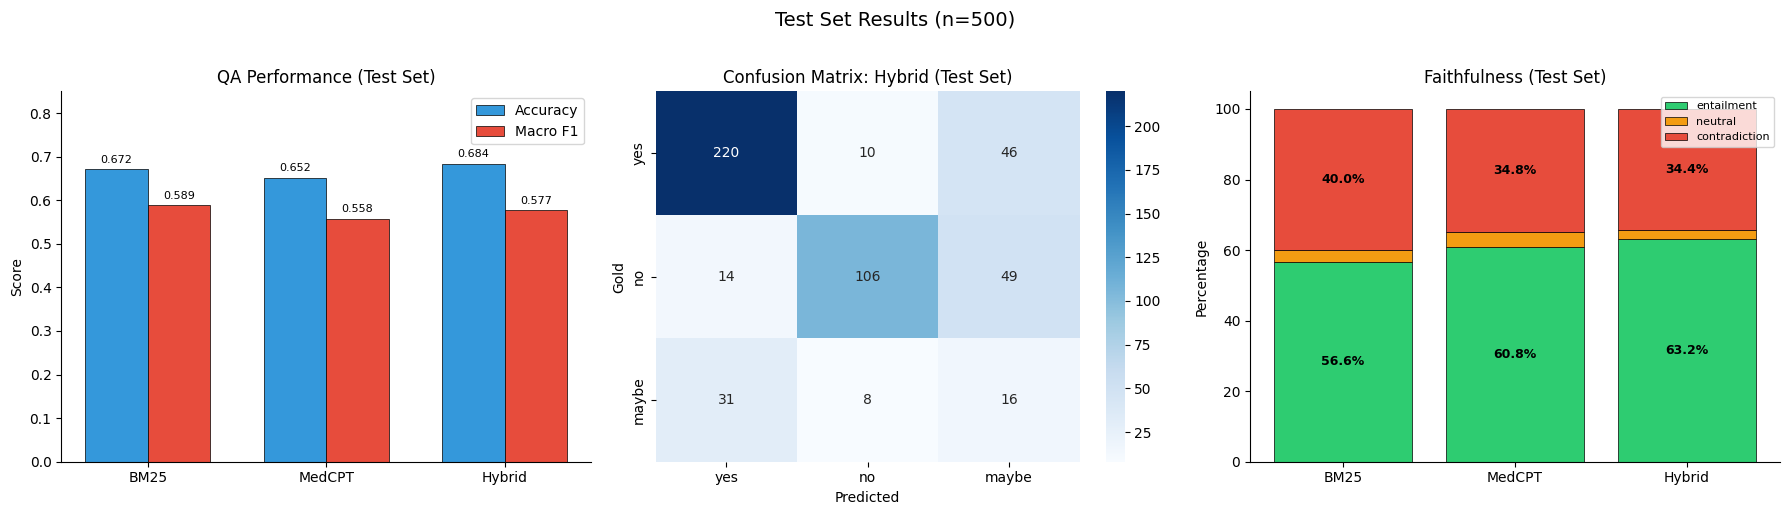

In [ ]:
# Test set visualisations

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: QA Performance comparison
methods = ['BM25', 'MedCPT', 'Hybrid']
acc_vals = [test_summary_df.loc[m, 'Accuracy'] for m in methods]
f1_vals = [test_summary_df.loc[m, 'Macro F1'] for m in methods]

x = np.arange(len(methods))
width = 0.35
bars1 = axes[0].bar(x - width/2, acc_vals, width, label='Accuracy',
                     color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, f1_vals, width, label='Macro F1',
                     color='#e74c3c', edgecolor='black', linewidth=0.5)
for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_ylabel('Score')
axes[0].set_title('QA Performance (Test Set)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].set_ylim(0, 0.85)
sns.despine(ax=axes[0])

# Panel 2: Confusion matrix for hybrid
labels_order = ['yes', 'no', 'maybe']
gold_test = [r['gold_label'] for r in test_pipeline_results['hybrid']]
pred_test = [r['predicted_label'] for r in test_pipeline_results['hybrid']]
cm_test = confusion_matrix(gold_test, pred_test, labels=labels_order)

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=labels_order, yticklabels=labels_order)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Gold')
axes[1].set_title('Confusion Matrix: Hybrid (Test Set)')

# Panel 3: Faithfulness by retriever
colors_faith = {'entailment': '#2ecc71', 'neutral': '#f39c12', 'contradiction': '#e74c3c'}
faith_labels_order = ['entailment', 'neutral', 'contradiction']

for i, (ret_name, results) in enumerate(test_pipeline_results.items()):
    faith_counts = Counter(r['faithfulness_label'] for r in results)
    total = len(results)
    bottom = 0
    for label in faith_labels_order:
        pct = faith_counts.get(label, 0) / total * 100
        axes[2].bar(i, pct, bottom=bottom, color=colors_faith[label],
                    edgecolor='black', linewidth=0.5,
                    label=label if i == 0 else "")
        if pct > 5:
            axes[2].text(i, bottom + pct/2, f'{pct:.1f}%',
                        ha='center', va='center', fontsize=9, fontweight='bold')
        bottom += pct

axes[2].set_xticks(range(3))
axes[2].set_xticklabels(['BM25', 'MedCPT', 'Hybrid'])
axes[2].set_ylabel('Percentage')
axes[2].set_title('Faithfulness (Test Set)')
axes[2].legend(loc='upper right', fontsize=8)
sns.despine(ax=axes[2])

plt.suptitle('Test Set Results (n=500)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'test_results_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Interactive Demo

A Gradio interface for exploring the RAG pipeline interactively. Select a retriever, enter a biomedical research question, and view the retrieved evidence, generated answer, and faithfulness assessment.

In [ ]:
# Interactive Gradio demo
!pip install -q gradio

import gradio as gr

# Sample questions for easy testing
SAMPLE_QUESTIONS = [
    "Does aspirin reduce the risk of heart attacks?",
    "Is vaccination effective against influenza in elderly patients?",
    "Do statins reduce mortality in patients with heart failure?",
    "Can exercise improve cognitive function in older adults?",
    "Is laparoscopic surgery safer than open surgery for appendectomy?",
]


def run_pipeline(question, retriever_name, num_passages):
    """Run the full RAG pipeline and return formatted results."""
    num_passages = int(num_passages)

    # Select retriever
    retriever_map = {
        "BM25 (Sparse)": retrieve_bm25,
        "MedCPT (Dense)": retrieve_dense,
        "Hybrid (BM25 + MedCPT)": retrieve_hybrid,
    }
    retrieve_fn = retriever_map[retriever_name]

    # Step 1: Retrieve
    results = retrieve_fn(question, k=num_passages)
    passages = get_retrieved_passages(results)

    # Step 2: Generate
    output = generate_answer(question, passages)

    # Step 3: Faithfulness check
    retrieved_context = " ".join([p['text'] for p in passages[:3]])
    faith = evaluate_faithfulness(retrieved_context, output.get('reasoning', ''))

    # Format retrieved passages
    passages_text = ""
    for i, p in enumerate(passages, 1):
        passages_text += f"**Passage {i}** (PubID: {p['pubid']}, Score: {p['score']:.4f})\n"
        passages_text += f"{p['text'][:300]}\n\n"

    # Format answer
    answer_text = f"### Answer: **{output['answer'].upper()}**\n\n"
    answer_text += f"**Reasoning:** {output['reasoning']}\n"

    # Format faithfulness
    faith_label = faith['label'].upper()
    faith_score = faith['entailment_score']

    if faith_label == "ENTAILMENT":
        faith_emoji = "✅"
        faith_desc = "Answer is supported by the retrieved evidence."
    elif faith_label == "CONTRADICTION":
        faith_emoji = "❌"
        faith_desc = "Answer contradicts the retrieved evidence."
    else:
        faith_emoji = "⚠️"
        faith_desc = "Answer is neither clearly supported nor contradicted."

    faith_text = f"### {faith_emoji} Faithfulness: **{faith_label}**\n\n"
    faith_text += f"**Entailment score:** {faith_score:.3f}\n\n"
    faith_text += f"{faith_desc}\n\n"
    faith_text += f"Scores - Entailment: {faith['scores']['entailment']:.3f}, "
    faith_text += f"Neutral: {faith['scores']['neutral']:.3f}, "
    faith_text += f"Contradiction: {faith['scores']['contradiction']:.3f}"

    return passages_text, answer_text, faith_text


# Build the interface
with gr.Blocks(
    title="Medical QA RAG: Faithfulness Evaluation",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown(
        """
        # 🏥 Medical QA RAG with Faithfulness Evaluation
        Enter a biomedical research question to see the full RAG pipeline in action:
        retrieval → generation → faithfulness assessment.

        *RAI-8001 Applied NLP Assessment 2*
        """
    )

    with gr.Row():
        with gr.Column(scale=3):
            question_input = gr.Textbox(
                label="Biomedical Research Question",
                placeholder="e.g., Does aspirin reduce the risk of heart attacks?",
                lines=2,
            )
        with gr.Column(scale=1):
            retriever_dropdown = gr.Dropdown(
                choices=["BM25 (Sparse)", "MedCPT (Dense)", "Hybrid (BM25 + MedCPT)"],
                value="Hybrid (BM25 + MedCPT)",
                label="Retriever",
            )
            num_passages_slider = gr.Slider(
                minimum=1, maximum=10, value=5, step=1,
                label="Number of passages (k)",
            )

    with gr.Row():
        submit_btn = gr.Button("Run Pipeline", variant="primary", scale=1)

    gr.Markdown("---")

    with gr.Row():
        with gr.Column():
            answer_output = gr.Markdown(label="Generated Answer")
        with gr.Column():
            faith_output = gr.Markdown(label="Faithfulness Assessment")

    passages_output = gr.Markdown(label="Retrieved Passages")

    # Sample questions
    gr.Markdown("### Try these sample questions:")
    gr.Examples(
        examples=[[q] for q in SAMPLE_QUESTIONS],
        inputs=[question_input],
    )

    submit_btn.click(
        fn=run_pipeline,
        inputs=[question_input, retriever_dropdown, num_passages_slider],
        outputs=[passages_output, answer_output, faith_output],
        show_progress="full",
    )

demo.launch(share=True)

/tmp/ipykernel_4231/1654096956.py:74: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://258bf560ebc7902bbe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
